In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py
import math
from scipy.stats import pearsonr # For correlation

# --- User's provided code for model, dataset, and evaluation function ---
# (This section is copied directly from the user's prompt)

def load_bin_events(path):
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]
    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)
    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)
    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid = raw[3::5].astype(np.uint32)
    t_low = raw[4::5].astype(np.uint32)
    t = (t_high << 16) | (t_mid << 8) | t_low
    return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment
        self.samples = []
        
        # Sprawdzenie, czy katalog główny zbioru danych istnieje
        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
        else:
            for cls in classes:
                class_path = self.root_dir / cls
                if not class_path.exists():
                    print(f"Warning: Class directory does not exist: {class_path}")
                    continue
                for f in class_path.glob("*.bin"):
                    self.samples.append((f, self.class_to_idx[cls]))
            if not self.samples:
                print(f"Warning: No event files found in {self.root_dir} for given classes.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_bin_events(path)
        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x
        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)
        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0
        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value
        return torch.from_numpy(voxels), torch.tensor(label)

class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)
    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)

class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module
    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out
        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None
    return ZIF.apply

class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)
        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0
    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]
        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]
        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_spikes += spike.sum().item()
        return torch.stack(spikes, dim=1)
    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)

def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x

class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)
    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

class VGG(nn.Module):
    ''' VGG model '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.4, **lif_parameters):
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p
        self.lif_modules = nn.ModuleList()
        self.features, out_c = make_layers(cfg, batch_norm, in_c, dropout_p=self.dropout_p, lif_modules=self.lif_modules, **lif_parameters)
        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x

def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.4, lif_modules=None, **lif_parameters):
    layers = []
    in_channels = in_c
    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1
    current_lif_count = 0
    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))]
        else:
            # Type casting to ensure integer, preventing TypeError
            try:
                in_channels_int = int(in_channels)
                v_val_int = int(v_val)
            except ValueError:
                raise ValueError(f"Expected integer for channel count, but got '{in_channels}' or '{v_val}' at layer {v_idx} in VGG config.")

            conv2d = SpikeModule(nn.Conv2d(in_channels_int, v_val_int, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters)
            if lif_modules is not None:
                lif_modules.append(lif)
            if batch_norm:
                bn = tdBatchNorm(v_val_int)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]
            current_lif_count += 1
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]
            in_channels = v_val_int # Update in_channels for the next layer

    return nn.Sequential(*layers), in_channels

cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}

def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)

def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)

def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

def evaluate(model, loader, device, criterion, classes):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)
            out_seq = model(x)
            out = out_seq.mean(1)
            loss = criterion(out, y)
            total_loss += loss.item()
            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    val_loss = total_loss / len(loader)
    val_acc = correct / total
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))
    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- End of user's provided code ---

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# Ścieżki bazowe dla wyników i wykresów (dostarczone przez użytkownika)
# Przystosowane do pracy niezależnie od systemu operacyjnego za pomocą pathlib
BASE_SNN_DIR = Path("C:/Users/Kacper/OneDrive/Desktop/SNN") # Katalog główny projektu SNN
EXPERIMENT_NAME = "results-real_101- VGG Net"

# Katalogi dla checkpointów i wykresów
RESULTS_DIR = BASE_SNN_DIR / "results" / EXPERIMENT_NAME
PLOTS_DIR = BASE_SNN_DIR / "plots" / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # Upewnienie się, że katalog na wykresy istnieje

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych (jak w skrypcie treningowym, ale z ostrzeżeniem dla lokalnego wykonania)
# Użytkownik podał "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
# Oznacza to, że zbiór danych N-Caltech101 powinien znajdować się lokalnie.
# Przyjmuję, że struktura będzie: BASE_SNN_DIR / N-Caltech101-full-split / N-Caltech101-full-split / (train|test)
TRAIN_ROOT = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "train"
TEST_ROOT = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "test"

# Wczytanie nazw klas do raportu klasyfikacji
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
            CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog główny danych treningowych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas z '{TRAIN_ROOT}': {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")
if not CLASSES:
    print("OSTRZEŻENIE: Nazwy klas są puste. Może to wpłynąć na etykiety raportu klasyfikacji i macierzy pomyłek.")

# Hiperparametry dla inicjalizacji modelu (muszą dokładnie odpowiadać treningowym)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_c": 2,
    "batch_norm": True,
    "thresh": 1.35,
    "tau": 0.9,
    "gamma": 1.0,
    "dropout_p": 0.3
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")
    print("Nie można wygenerować wizualizacji bez historii treningu. Upewnij się, że ścieżka jest poprawna.")

# Upewnienie się, że historia ma wszystkie oczekiwane klucze, w razie potrzeby dostarczając wartości domyślne
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate"]
    for key in expected_keys:
        if key not in history:
            history[key] = []
            print(f"Ostrzeżenie: Klucz '{key}' nie znaleziony w historii. Zainicjowano jako pustą listę.")
else:
    print("Ostrzeżenie: Historia nie została wczytana, pomijam generowanie wykresów opartych na historii.")


# --- ZMODYFIKOWANO: 1. i 2. Krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and history["epoch"] and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True) # Two subplots, one row, constrained layout

    # Plot Loss Curve
    if history["train_loss"] and history["val_loss"]:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o stracie w historii. Nie można wygenerować wykresu straty.")
        axes[0].set_title("Brak danych o stracie")

    # Plot Accuracy Curve (without val_acc as it overlaps with Top-1)
    if history["train_acc"]: # val_acc is removed per request
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o dokładności w historii. Nie można wygenerować wykresu dokładności.")
        axes[1].set_title("Brak danych o dokładności")

    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")
else:
    print("Ostrzeżenie: Brak danych w historii. Pomijam wykresy straty i dokładności.")


# --- 3. Średnia częstość wyładowań (mean_spike_rate.png) ---
if history and history["spike_rate"] and history["epoch"] and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list) and len(history["spike_rate"][0]) > 0:
            num_layers = len(history["spike_rate"][0])
            spike_rates_per_layer = [[] for _ in range(num_layers)]
            
            # Fill spike_rates_per_layer, handling potential inconsistencies with NaNs
            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        spike_rates_per_layer[i].append(epoch_rates[i])
                else:
                    # If an epoch has inconsistent spike_rate data, append NaNs
                    print(f"Ostrzeżenie: Niespójne dane 'spike_rate' w epoce {history['epoch'][epoch_idx]}. Dodano NaN.")
                    for i in range(num_layers):
                        spike_rates_per_layer[i].append(np.nan)
            
            plt.figure(figsize=(12, 7), constrained_layout=True) # constrained layout
            for i, layer_rates in enumerate(spike_rates_per_layer):
                # Only plot if there's actual data for the layer (not all NaNs)
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            # plt.tight_layout() # constrained_layout handles this
            plt.savefig(PLOTS_DIR / "mean_spike_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_spike_rate.png'}")
        else:
            print("Ostrzeżenie: Lista częstości wyładowań w historii jest pusta lub ma nieoczekiwany format. Pomijam wykres częstości wyładowań.")
    else:
        print("Ostrzeżenie: Dane o częstości wyładowań są puste. Pomijam wykres częstości wyładowań.")
else:
    print("Ostrzeżenie: Brak danych o częstości wyładowań lub epokach w historii. Pomijam wykres częstości wyładowań.")


# --- 4. Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    
    # Spłaszczenie listy spike_rate do oddzielnych kolumn dla CSV
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"spike_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)
            
        else:
            print("Ostrzeżenie: Kolumna 'spike_rate' nie zawiera list (lub jest pusta). Nie zostanie spłaszczona do warstw.")
    
    # Calculate average spike rate per epoch and add to df_history
    if "spike_rate" in history and history["spike_rate"] and isinstance(history["spike_rate"][0], list):
        avg_spike_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_spike_rate"] = pd.Series(avg_spike_rate_per_epoch, index=df_history.index) # Use existing index
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        # If spike_rate column already exists but wasn't a list of lists, treat it as single value
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_spike_rate"] = df_history["spike_rate"]


    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")
else:
    print("Ostrzeżenie: Brak danych historii do zapisania w CSV.")

# --- Przygotowanie do Macierzy Pomyłek i Raportu Klasyfikacji ---
# Inicjalizacja modelu i kryterium straty
try:
    model = vgg11(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu VGG11: {e}")
    print("Sprawdź, czy parametry 'in_c', 'num_classes' i wartości w 'cfg' są poprawne (int).")
    model = None # Set model to None to prevent further errors

all_labels = None
all_probs = None
all_preds = None
val_acc_final = 0.0
top1_final = 0.0
top5_final = 0.0

# Zmienne dla wersji weighted
final_precision_weighted = 0.0
final_recall_weighted = 0.0
final_f1_weighted = 0.0

# Zmienne dla wersji macro
final_precision_macro = 0.0
final_recall_macro = 0.0
final_f1_macro = 0.0

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do końcowej ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval() # Ustawienie modelu w tryb ewaluacji

        # Sprawdzenie, czy katalog TEST_ROOT istnieje przed próbą wczytania zbioru danych
        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka do zbioru testowego '{TEST_ROOT}' nie istnieje lokalnie.")
            print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            print("Upewnij się, że zbiór danych N-Caltech101 jest poprawnie umieszczony, a ścieżki są zaktualizowane dla lokalnego wykonania.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Nie znaleziono żadnych próbek w zbiorze testowym pod '{TEST_ROOT}'.")
                print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            else:
                # num_workers=0 dla lepszej kompatybilności z Windows
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)
                
                # Calculate Precision, Recall, F1-Score (weighted average)
                p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_weighted = p_weighted
                final_recall_weighted = r_weighted
                final_f1_weighted = f1_weighted

                # Calculate Precision, Recall, F1-Score (macro average)
                p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )
                final_precision_macro = p_macro
                final_recall_macro = r_macro
                final_f1_macro = f1_macro


                print(f"Końcowa dokładność testowa: {val_acc_final*100:.2f}%")
                print(f"Końcowa dokładność Top-1: {top1_final*100:.2f}%")
                print(f"Końcowa dokładność Top-5: {top5_final*100:.2f}%")
                print(f"Końcowa precyzja (weighted): {final_precision_weighted*100:.2f}%")
                print(f"Końcowy recall (weighted): {final_recall_weighted*100:.2f}%")
                print(f"Końcowy F1-score (weighted): {final_f1_weighted*100:.2f}%")
                print(f"Końcowa precyzja (macro): {final_precision_macro*100:.2f}%")
                print(f"Końcowy recall (macro): {final_recall_macro*100:.2f}%")
                print(f"Końcowy F1-score (macro): {final_f1_macro*100:.2f}%")

    except Exception as e:
        print(f"Błąd podczas ładowania lub ewaluacji najlepszego modelu: {e}")
else:
    print(f"Błąd: Model nie został zainicjalizowany lub plik najlepszego modelu nie znaleziony pod {BEST_MODEL_PATH}.")
    print("Nie można wygenerować macierzy pomyłek ani raportu klasyfikacji bez wytrenowanego modelu.")

# --- 5. Macierz Pomyłek (confusion_matrix.png) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 1: # Potrzebujemy co najmniej 2 klas dla macierzy pomyłek
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True) # constrained layout
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print("Ostrzeżenie: Pomijam macierz pomyłek z powodu braku danych ewaluacyjnych lub niewystarczającej liczby klas.")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0) # zero_division=0 zapobiega błędom dla klas bez próbek
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(report)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")
    print("\n" + report)
else:
    print("Ostrzeżenie: Pomijam raport klasyfikacji z powodu braku danych ewaluacyjnych lub braku zdefiniowanych klas.")

# --- Dodatkowe wizualizacje ---

# 1. Rozkład częstości wyładowań w ostatniej epoce (Bar plot)
if history and history["spike_rate"] and history["epoch"] and len(history["spike_rate"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_spike_rates = history["spike_rate"][-1] # Częstości z ostatniej epoki
        layer_names = [f"LIF {i+1}" for i in range(len(final_spike_rates))]

        plt.figure(figsize=(10, 6), constrained_layout=True) # constrained layout
        sns.barplot(x=layer_names, y=final_spike_rates, palette="viridis")
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość wyładowań")
        plt.title("Średnia częstość wyładowań na warstwę LIF (ostatnia epoka)")
        plt.xticks(rotation=45, ha='right')
        # plt.tight_layout() # constrained_layout handles this
        plt.savefig(PLOTS_DIR / "final_spike_rate_distribution.png")
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_spike_rate_distribution.png'}")
    else:
        print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (dane nie są w formacie listy).")
else:
    print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (brak dostępnych danych).")

# 2. Dokładność per klasa (Bar plot)
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0] # Get array of indices
        if len(class_indices) > 0: # Upewnienie się, że są próbki dla danej klasy
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0 # Brak próbek dla tej klasy w zbiorze testowym

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True) # constrained layout
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")
else:
    print("Pomijam wykres dokładności per klasa (brak dostępnych danych ewaluacyjnych lub brak zdefiniowanych klas).")


# --- NOWE WIZUALIZACJE ---

# Wymagane dane dla nowych wykresów
val_accs_for_plots = []
avg_spike_rates_for_plots = []
correlation = np.nan # Initialize correlation for report

if history and history["val_acc"] and history["spike_rate"] and history["epoch"]:
    # Oblicz średnią częstość wyładowań na epokę
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]): # Ensure val_acc data exists for this epoch
            avg_spike_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
        else:
            avg_spike_rates_for_plots.append(np.nan)
            val_accs_for_plots.append(np.nan)
    
    # Filter out NaNs if any, ensure lists are same length
    valid_data_points = [(sr, va, epoch) for sr, va, epoch in zip(avg_spike_rates_for_plots, val_accs_for_plots, history["epoch"]) if not np.isnan(sr) and not np.isnan(va)]
    
    if valid_data_points:
        avg_spike_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]
    else:
        avg_spike_rates_for_plots = []
        val_accs_for_plots = []
        epochs_for_plots = []
        print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresów 'częstość wyładowań vs accuracy' i 'korelacji'.")
else:
    print("Ostrzeżenie: Brak historii treningu lub kluczy 'val_acc', 'spike_rate', 'epoch' w historii. Pomijam nowe wykresy.")


# ZMODYFIKOWANO: Wykres 1: Analiza częstości wyładowań vs accuracy (Średnia częstość wyładowań vs Dokładność Walidacyjna w czasie)
if val_accs_for_plots and avg_spike_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True) # Zwiększono szerokość wykresu i dodano constrained_layout

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    # ZMODYFIKOWANO: Oś Y po prawej stronie na procenty
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color) # Zmieniona etykieta
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_spike_rates_for_plots], color=color, marker='x', linestyle='--') # Pomnożono przez 100
    ax2.tick_params(axis='y', labelcolor=color)

    # ZMODYFIKOWANO: Tytuł na polski i zmieniono "spikowania" na "wyładowań"
    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16) # Używamy suptitle dla tytułu figury
    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "spike_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'spike_rate_vs_val_acc_over_epochs.png'}")

    # A better way to visualize SR vs Acc is often a scatter plot directly
    plt.figure(figsize=(10, 6), constrained_layout=True) # constrained layout
    sns.scatterplot(x=[sr * 100 for sr in avg_spike_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots], hue=epochs_for_plots, palette="viridis", legend=False, size=epochs_for_plots, sizes=(50, 200))
    plt.xlabel("Średnia częstość wyładowań (%)") # Zmieniono na "wyładowań"
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)") # Zmieniono na "wyładowań"
    plt.grid(True)
    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "avg_spike_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_spike_rate_vs_val_acc_scatter.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresu 'Średnia częstość wyładowań vs Dokładność Walidacyjna'.")


# Wykres 2: Korelacja częstość wyładowań <-> val_acc
if len(val_accs_for_plots) > 1 and len(avg_spike_rates_for_plots) > 1: # Need at least 2 points for correlation
    correlation, _ = pearsonr(avg_spike_rates_for_plots, val_accs_for_plots)
    print(f"\nKorelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True) # constrained layout
    sns.regplot(x=np.array(avg_spike_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    # USTAWIENIE ZAKRESU OSI Y NA 0-100
    plt.ylim(0, 100)
    # plt.tight_layout() # constrained_layout handles this
    plt.savefig(PLOTS_DIR / "correlation_spike_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_spike_rate_val_acc.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych (min. 2 punkty) do wygenerowania wykresu korelacji 'częstość wyładowań <-> val_acc'.")


# --- 7. Raport Eksperymentu (raport_eksperymentu.pdf) ---
print(f"\nAby utworzyć 'raport_eksperymentu.pdf':")
print(f"Wygenerowano raport w formacie Markdown ('raport_eksperymentu.md') w katalogu {PLOTS_DIR}.")
print(f"Możesz przekonwertować ten plik Markdown do formatu PDF za pomocą narzędzi takich jak Pandoc.")
print(f"Przykładowe polecenie (uruchom w terminalu po zainstalowaniu Pandoc):")
print(f"  `pandoc \"{PLOTS_DIR / 'raport_eksperymentu.md'}\" -o \"{PLOTS_DIR / 'raport_eksperymentu.pdf'}\"`")
print(f"Alternatywnie, możesz użyć bibliotek Pythona, takich jak 'ReportLab' lub 'Fpdf', aby programowo wygenerować plik PDF, osadzając obrazy i tekst.")

report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) VGG11

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

**Lokalizacja wyników treningu:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu

Model: VGG11
Typ sieci: Sieć Impulsowa (SNN) z neuronami LIF (Leaky Integrate-and-Fire)
Zbiór danych: N-Caltech101
Liczba klas: {NUM_CLASSES}
Liczba epok treningowych (z checkpointu): {history["epoch"][-1] if history and history["epoch"] else 'N/A'}
Urządzenie: {device}

**Parametry neuronu LIF:**
*   Próg (Threshold, `thresh`): {MODEL_PARAMS['thresh']}
*   Stała czasowa (Time Constant, `tau`): {MODEL_PARAMS['tau']}
*   Parametr nachylenia funkcji surrogatowej (Slope Parameter, `gamma`): {MODEL_PARAMS['gamma']}

**Inne parametry:**
*   Prawdopodobieństwo Dropoutu (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Normalizacja wsadowa (Batch Normalization): {MODEL_PARAMS['batch_norm']}
*   Kroki czasowe (Time Steps, `T`): {DATASET_T}

---

## Wyniki Treningu i Walidacji (z historii)

Poniżej przedstawiono podsumowanie wyników treningu i walidacji w czasie kolejnych epok. Szczegółowe dane liczbowe znajdują się w pliku `metrics.csv`.

### Krzywe Straty i Dokładności
*Plik: loss_accuracy_curves.png*
(Wykresy przedstawiają wartości straty treningowej i walidacyjnej oraz dokładność treningową, Top-1 i Top-5 w zależności od epoki treningu.)

### Średnia Częstość Wyładowań Neuronów LIF
*Plik: mean_spike_rate.png*
(Wykres przedstawia średnią częstość wyładowań dla każdej warstwy LIF w sieci, w funkcji epok. Optymalnie, wartości te powinny mieścić się w rozsądnym zakresie, np. 0.01-0.1, aby zapewnić efektywne uczenie bez nadmiernej aktywności lub 'cichych' neuronów.)

### Metryki Treningowe i Walidacyjne (CSV)
*Plik: metrics.csv*
(Plik CSV zawierający szczegółowe metryki dla każdej epoki, takie jak strata treningowa i walidacyjna, dokładność, Top-1, Top-5 oraz średnia częstość wyładowań dla każdej warstwy LIF.)

---

## Wyniki Ewaluacji na Zbiorze Testowym (Najlepszy Model)

Poniższe wyniki zostały uzyskane na niezależnym zbiorze testowym przy użyciu modelu, który osiągnął najlepszą dokładność walidacyjną podczas treningu.

"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (Val Accuracy z checkpointu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (osiągnięta w epoce {history["epoch"][np.argmax(history["val_acc"])] if history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Test Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Precision) na Zbiorze Testowym (Weighted Average):** {final_precision_weighted*100:.2f}%
*   **Recall na Zbiorze Testowym (Weighted Average):** {final_recall_weighted*100:.2f}%
*   **F1-Score na Zbiorze Testowym (Weighted Average):** {final_f1_weighted*100:.2f}%
*   **Precyzja (Precision) na Zbiorze Testowym (Macro Average):** {final_precision_macro*100:.2f}%
*   **Recall na Zbiorze Testowym (Macro Average):** {final_recall_macro*100:.2f}%
*   **F1-Score na Zbiorze Testowym (Macro Average):** {final_f1_macro*100:.2f}%

### Raport Klasyfikacji
*Plik: classification_report.txt*
{classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)}
### Macierz Pomyłek
*Plik: confusion_matrix.png*
(Wizualizacja macierzy pomyłek przedstawiająca, jak dobrze model klasyfikował każdą klasę na zbiorze testowym. Przekątna macierzy wskazuje liczbę poprawnych klasyfikacji dla każdej klasy.)
"""
else:
    report_content += """
*(Brak pełnych wyników ewaluacji na zbiorze testowym z powodu problemów z ładowaniem danych lub modelu. Upewnij się, że ścieżki do danych testowych są poprawne i że plik 'best_model.pth' jest dostępny.)*
"""

report_content += f"""
---

## Dodatkowe Wizualizacje i Analizy

### Rozkład Częstości Wyładowań w Ostatniej Epoce
*Plik: final_spike_rate_distribution.png*
(Wykres słupkowy pokazujący średnie częstości wyładowań dla każdej warstwy LIF w ostatniej zakończonej epoce treningu. Pomaga to zrozumieć końcowy rozkład aktywności w warstwach sieci.)

### Dokładność per Klasa
*Plik: per_class_accuracy.png*
(Wykres słupkowy prezentujący dokładność modelu dla każdej pojedynczej klasy na zbiorze testowym. Umożliwia identyfikację klas, które są dla modelu łatwiejsze lub trudniejsze do sklasyfikowania.)

### Analiza: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna w Funkcji Epok
*Plik: spike_rate_vs_val_acc_over_epochs.png*
(Wykres liniowy prezentujący trend zmian średniej częstości wyładowań (uśrednionej dla wszystkich warstw LIF) oraz dokładności walidacyjnej w funkcji epok. Pozwala zaobserwować, czy istnieje widoczna zależność między aktywnością sieci a jej wydajnością w trakcie uczenia.)

### Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)
*Plik: avg_spike_rate_vs_val_acc_scatter.png*
(Wykres rozrzutu przedstawiający bezpośrednią relację między średnią częstością wyładowań a dokładnością walidacyjną. Punkty są kolorowane i rozmiarowane na podstawie numeru epoki, co pozwala śledzić ewolucję tej zależności w czasie.)

### Korelacja: Średnia Częstość Wyładowań ↔ Dokładność Walidacyjna
*Plik: correlation_spike_rate_val_acc.png*
(Wykres rozrzutu z linią regresji wizualizujący korelację między średnią częstością wyładowań a dokładnością walidacyjną. Oś Y jest ograniczona do realistycznego zakresu 0-100%. Wartość współczynnika korelacji Pearsona, {correlation:.2f} (jeśli obliczona), wskazuje na siłę i kierunek tej liniowej zależności, gdzie:
*   `r > 0` oznacza korelację pozytywną (wzrost jednego prowadzi do wzrostu drugiego)
*   `r < 0` oznacza korelację negatywną (wzrost jednego prowadzi do spadku drugiego)
*   `r` bliskie `0` oznacza brak liniowej korelacji
Idealnie, sieć powinna uczyć się i osiągać wysoką dokładność przy kontrolowanym (niekoniecznie bardzo niskim) poziomie częstości wyładowań.)

---

## Dalsze Propozycje Wizualizacji / Analiz

*   **Krzywa współczynnika uczenia (Learning Rate Curve):** Jeśli współczynnik uczenia był logowany w historii (np. do historii byłaby dodana lista `lr`), można go wykreślić, aby zobaczyć, jak zmieniał się w trakcie treningu i czy harmonogram uczenia działał zgodnie z oczekiwaniami.
*   **Przykładowe predykcje z wizualizacją danych zdarzeń:** Wizualizacja kilku przykładów wejściowych (np. zrekonstruowanych z danych zdarzeń) wraz z prawdziwą etykietą i przewidywaną etykietą modelu (zwłaszcza dla błędnych predykcji) może dostarczyć cennych informacji jakościowych. Wymaga to jednak dodatkowej logiki do renderowania danych zdarzeń jako obrazów.
*   **Analiza rozkładu potencjałów membranowych (Membrane Potential Distribution):** Wizualizacja rozkładu potencjału membranowego neuronów w różnych warstwach SNN może pomóc w debugowaniu problemów z ich aktywacją (np. zbyt często spikują lub są 'ciche').

"""
# Update correlation value in the report if it was calculated
if not np.isnan(correlation):
    report_content = report_content.replace("{correlation:.2f}", f"{correlation:.2f}")
else:
    report_content = report_content.replace("{correlation:.2f}", "N/A (brak danych)")


with open(PLOTS_DIR / "raport_eksperymentu.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print(f"Wygenerowano raport w formacie Markdown pod ścieżką: {PLOTS_DIR / 'raport_eksperymentu.md'}")

print("\nWszystkie żądane wizualizacje i raporty zostały przetworzone (lub pominięte, jeśli brakowało danych).")
print(f"Sprawdź katalog '{PLOTS_DIR}' w poszukiwaniu plików wyjściowych.")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_101- VGG Net\checkpoint.pth...
Historia wczytana pomyślnie.
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\loss_accuracy_curves.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\mean_spike_rate.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\metrics.csv
Wczytywanie najlepszego modelu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_101- VGG Net\best_model.pth do końcowej ewaluacji...
Ewaluacja najlepszego modelu na zbiorze testowym...
Końcowa dokładność testowa: 76.70%
Końcowa dokładność Top-1: 76.70%
Końcowa dokładność Top-5: 90.60%
Końcowa precyzja (weighted): 78.68%
Końcowy recall (weighted): 76.70%
Końcowy F1-score (weighted): 75.87%
Końcowa precyzja (macro): 70.57%
Końcowy recall (macro): 71.91%
Końcowy F1-score (macro): 69.66%
Wyg

Wygenerowano raport w formacie Markdown pod ścieżką: C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\raport_eksperymentu.md

Wszystkie żądane wizualizacje i raporty zostały przetworzone (lub pominięte, jeśli brakowało danych).
Sprawdź katalog 'C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net' w poszukiwaniu plików wyjściowych.


In [19]:
print("--- Generowanie dodatkowych wykresów (nowa komórka) ---")

# Zapewnienie, że wymagane listy dla wykresów spike rate są dostępne
val_accs_for_plots = []
avg_spike_rates_for_plots = []
epochs_for_plots = []
correlation = np.nan

if history and history["val_acc"] and history["spike_rate"] and history["epoch"]:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_spike_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])
        else:
            # Handle inconsistent data by not appending, or by appending NaN if explicitly needed
            pass # We'll filter NaNs later if they somehow get in

    # Filter out NaNs if any, ensure lists are same length and contain valid data
    valid_data_points = [(sr, va, epoch) for sr, va, epoch in zip(avg_spike_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    
    if valid_data_points:
        avg_spike_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]
    else:
        avg_spike_rates_for_plots = []
        val_accs_for_plots = []
        epochs_for_plots = []
        print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresów 'spike rate vs accuracy' i 'korelacji' w tej komórce.")
else:
    print("Ostrzeżenie: Brak historii treningu lub kluczy 'val_acc', 'spike_rate', 'epoch' w historii. Pomijam wykresy w tej komórce.")


# --- 1. Samo accuracy dla zbioru treningowego i walidacyjnego ---
if history and history["train_acc"] and history["val_acc"] and history["epoch"] and len(history["epoch"]) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
    plt.plot(history["epoch"], [acc * 100 for acc in history["val_acc"]], label="Dokładność walidacyjna")
    plt.xlabel("Epoka")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność Treningowa i Walidacyjna")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 100) # Ograniczenie osi Y do realistycznego zakresu procentowego
    plt.savefig(PLOTS_DIR / "train_val_accuracy_only.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'train_val_accuracy_only.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresu 'Dokładność Treningowa i Walidacyjna'.")

# --- 2. Analiza spike rate vs accuracy (Średnia częstość spikowania vs Dokładność Walidacyjna w czasie) ---
if val_accs_for_plots and avg_spike_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 7))

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100) # Ograniczenie osi Y

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia częstość spikowania", color=color)
    ax2.plot(epochs_for_plots, avg_spike_rates_for_plots, color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)
    # Można też ustawić limit dla spike rate, np. plt.ylim(0, 0.2) jeśli to są małe wartości

    fig.tight_layout()
    plt.title("Średnia częstość spikowania i Dokładność Walidacyjna w czasie")
    plt.savefig(PLOTS_DIR / "spike_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'spike_rate_vs_val_acc_over_epochs.png'}")

    # Wykres rozrzutu (scatter plot) bez legendy
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=[sr * 100 for sr in avg_spike_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots], 
                    hue=epochs_for_plots, palette="viridis", legend=False, 
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość spikowania (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Spikowania vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100) # Ograniczenie osi Y
    plt.savefig(PLOTS_DIR / "avg_spike_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_spike_rate_vs_val_acc_scatter.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresu 'Średnia częstość spikowania vs Dokładność Walidacyjna'.")


# --- 3. Korelacja spike_rate <-> val_acc ---
if len(val_accs_for_plots) > 1 and len(avg_spike_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_spike_rates_for_plots, val_accs_for_plots)
    print(f"\nKorelacja Pearsona (Avg Spike Rate vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6))
    sns.regplot(x=np.array(avg_spike_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100, 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość spikowania (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Spikowania vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100) # Ograniczenie osi Y do 0-100%
    plt.savefig(PLOTS_DIR / "correlation_spike_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_spike_rate_val_acc.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych (min. 2 punkty) do wygenerowania wykresu korelacji 'spike_rate <-> val_acc'.")


# --- 4. Rozkład częstości spikowania w ostatniej epoce (Bar plot) ---
if history and history["spike_rate"] and history["epoch"] and len(history["spike_rate"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_spike_rates = history["spike_rate"][-1]
        layer_names = [f"LIF {i+1}" for i in range(len(final_spike_rates))]

        plt.figure(figsize=(10, 6))
        sns.barplot(x=layer_names, y=final_spike_rates, palette="viridis")
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość spikowania")
        plt.title("Średnia częstość spikowania na warstwę LIF (ostatnia epoka)")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "final_spike_rate_distribution.png")
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_spike_rate_distribution.png'}")
    else:
        print("Pomijam wykres rozkładu częstości spikowania w ostatniej epoce (dane nie są w formacie listy).")
else:
    print("Pomijam wykres rozkładu częstości spikowania w ostatniej epoce (brak dostępnych danych).")


# --- 5. Dokładność per klasa (Bar plot) ---
# Zakłada, że 'all_labels', 'all_preds', 'CLASSES' są dostępne z poprzedniej komórki
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8))
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.ylim(0, 100) # Ograniczenie osi Y
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")
else:
    print("Ostrzeżenie: Pomijam wykres dokładności per klasa (brak dostępnych danych ewaluacyjnych lub brak zdefiniowanych klas).")
    
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) VGG11

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

**Lokalizacja wyników treningu:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu

Model: VGG11
Typ sieci: Sieć Impulsowa (SNN) z neuronami LIF (Leaky Integrate-and-Fire)
Zbiór danych: N-Caltech101
Liczba klas: {NUM_CLASSES}
Liczba epok treningowych (z checkpointu): {history["epoch"][-1] if history and history["epoch"] else 'N/A'}
Urządzenie: {device}

**Parametry neuronu LIF:**
*   Próg (Threshold, `thresh`): {MODEL_PARAMS['thresh']}
*   Stała czasowa (Time Constant, `tau`): {MODEL_PARAMS['tau']}
*   Parametr nachylenia funkcji surrogatowej (Slope Parameter, `gamma`): {MODEL_PARAMS['gamma']}

**Inne parametry:**
*   Prawdopodobieństwo Dropoutu (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Normalizacja wsadowa (Batch Normalization): {MODEL_PARAMS['batch_norm']}
*   Kroki czasowe (Time Steps, `T`): {DATASET_T}

---

## Wyniki Treningu i Walidacji (z historii)

Poniżej przedstawiono podsumowanie wyników treningu i walidacji w czasie kolejnych epok. Szczegółowe dane liczbowe znajdują się w pliku `metrics.csv`.

### Krzywe Straty
*Plik: loss_curve.png*
(Wykres przedstawia wartości straty treningowej i walidacyjnej w zależności od epoki treningu.)

### Krzywe Dokładności (z Top-K)
*Plik: accuracy_curve.png*
(Wykres przedstawia dokładność treningową, walidacyjną, dokładność Top-1 oraz Top-5 w zależności od epoki.)

### Dokładność Treningowa i Walidacyjna (uproszczona)
*Plik: train_val_accuracy_only.png*
(Uproszczony wykres przedstawiający wyłącznie dokładność treningową i walidacyjną w zależności od epoki, co pozwala na szybki przegląd podstawowych metryk wydajności modelu.)

### Średnia Częstość Spikowania Neuronów LIF
*Plik: mean_spike_rate.png*
(Wykres przedstawia średnią częstość spikowania dla każdej warstwy LIF w sieci, w funkcji epok. Optymalnie, wartości te powinny mieścić się w rozsądnym zakresie, np. 0.01-0.1, aby zapewnić efektywne uczenie bez nadmiernej aktywności lub 'cichych' neuronów.)

### Metryki Treningowe i Walidacyjne (CSV)
*Plik: metrics.csv*
(Plik CSV zawierający szczegółowe metryki dla każdej epoki, takie jak strata treningowa i walidacyjna, dokładność, Top-1, Top-5 oraz średnia częstość spikowania dla każdej warstwy LIF.)

---

## Wyniki Ewaluacji na Zbiorze Testowym (Najlepszy Model)

Poniższe wyniki zostały uzyskane na niezależnym zbiorze testowym przy użyciu modelu, który osiągnął najlepszą dokładność walidacyjną podczas treningu.

"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (Val Accuracy z checkpointu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (osiągnięta w epoce {history["epoch"][np.argmax(history["val_acc"])] if history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Test Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%

### Raport Klasyfikacji
*Plik: classification_report.txt*
{classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)}
"""
else:
    report_content += """
*(Brak pełnych wyników ewaluacji na zbiorze testowym z powodu problemów z ładowaniem danych lub modelu. Upewnij się, że ścieżki do danych testowych są poprawne i że plik 'best_model.pth' jest dostępny.)*
"""

report_content += f"""
---

## Dodatkowe Wizualizacje i Analizy

### Rozkład Częstości Spikowania w Ostatniej Epoce
*Plik: final_spike_rate_distribution.png*
(Wykres słupkowy pokazujący średnie częstości spikowania dla każdej warstwy LIF w ostatniej zakończonej epoce treningu. Pomaga to zrozumieć końcowy rozkład aktywności w warstwach sieci.)

### Dokładność per Klasa
*Plik: per_class_accuracy.png*
(Wykres słupkowy prezentujący dokładność modelu dla każdej pojedynczej klasy na zbiorze testowym. Umożliwia identyfikację klas, które są dla modelu łatwiejsze lub trudniejsze do sklasyfikowania.)

### Analiza: Średnia Częstość Spikowania vs. Dokładność Walidacyjna w Czasie
*Plik: spike_rate_vs_val_acc_over_epochs.png*
(Wykres liniowy prezentujący trend zmian średniej częstości spikowania (uśrednionej dla wszystkich warstw LIF) oraz dokładności walidacyjnej w funkcji epok. Pozwala zaobserwować, czy istnieje widoczna zależność między aktywnością sieci a jej wydajnością w trakcie uczenia.)

### Zależność: Średnia Częstość Spikowania vs. Dokładność Walidacyjna (z epoką)
*Plik: avg_spike_rate_vs_val_acc_scatter.png*
(Wykres rozrzutu przedstawiający bezpośrednią relację między średnią częstością spikowania a dokładnością walidacyjną. Punkty są kolorowane i rozmiarowane na podstawie numeru epoki, co pozwala śledzić ewolucję tej zależności w czasie. Legenda została usunięta dla lepszej czytelności.)

### Korelacja: Średnia Częstość Spikowania ↔ Dokładność Walidacyjna
*Plik: correlation_spike_rate_val_acc.png*
(Wykres rozrzutu z linią regresji wizualizujący korelację między średnią częstością spikowania a dokładnością walidacyjną. Oś Y jest ograniczona do realistycznego zakresu 0-100%. Wartość współczynnika korelacji Pearsona, {correlation:.2f} (jeśli obliczona), wskazuje na siłę i kierunek tej liniowej zależności, gdzie:
*   `r > 0` oznacza korelację pozytywną (wzrost jednego prowadzi do wzrostu drugiego)
*   `r < 0` oznacza korelację negatywną (wzrost jednego prowadzi do spadku drugiego)
*   `r` bliskie `0` oznacza brak liniowej korelacji
Idealnie, sieć powinna uczyć się i osiągać wysoką dokładność przy kontrolowanym (niekoniecznie bardzo niskim) poziomie częstości spikowania.)

---

## Dalsze Propozycje Wizualizacji / Analiz

*   **Przykładowe predykcje z wizualizacją danych zdarzeń:** Wizualizacja kilku przykładów wejściowych (np. zrekonstruowanych z danych zdarzeń) wraz z prawdziwą etykietą i przewidywaną etykietą modelu (zwłaszcza dla błędnych predykcji) może dostarczyć cennych informacji jakościowych. Wymaga to jednak dodatkowej logiki do renderowania danych zdarzeń jako obrazów.
*   **Analiza rozkładu potencjałów membranowych (Membrane Potential Distribution):** Wizualizacja rozkładu potencjału membranowego neuronów w różnych warstwach SNN może pomóc w debugowaniu problemów z ich aktywacją (np. zbyt często spikują lub są 'ciche').

"""
# Update correlation value in the report if it was calculated
if not np.isnan(correlation):
    report_content = report_content.replace("{correlation:.2f}", f"{correlation:.2f}")
else:
    report_content = report_content.replace("{correlation:.2f}", "N/A (brak danych)")


with open(PLOTS_DIR / "raport_eksperymentu.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print(f"Wygenerowano zaktualizowany raport w formacie Markdown pod ścieżką: {PLOTS_DIR / 'raport_eksperymentu.md'}")

print("\nWszystkie żądane wizualizacje zostały przetworzone (lub pominięte, jeśli brakowało danych).")
print(f"Sprawdź katalog '{PLOTS_DIR}' w poszukiwaniu plików wyjściowych.")

--- Generowanie dodatkowych wykresów (nowa komórka) ---
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\train_val_accuracy_only.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\spike_rate_vs_val_acc_over_epochs.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\avg_spike_rate_vs_val_acc_scatter.png

Korelacja Pearsona (Avg Spike Rate vs. Val Accuracy): 0.8857
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\correlation_spike_rate_val_acc.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\final_spike_rate_distribution.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\per_class_accuracy.png
Wygenerowano zaktualizowany raport w formacie Markdown pod ścieżką: C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101- VGG Net\raport_eksperymentu.md

Wszystkie żądane wizualizacje zos

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py # Import for H5 data
import math
from scipy.stats import pearsonr # For correlation

# --- User's provided code for model, dataset, and evaluation function ---

# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []
        
        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
            return # Exit early if root_dir doesn't exist

        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"): # Szukamy plików .h5
                self.samples.append((f, self.class_to_idx[cls]))
        
        if not self.samples:
            print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .h5).")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            # Zwróć tensor zer o odpowiednim kształcie i etykietę, jeśli brak zdarzeń
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        # Handle cases where t.max() - t.min() is 0 (single event or all events at same time)
        t_min = t.min()
        t_max = t.max()
        if (t_max - t_min) < 1e-9: # Avoid division by zero
            t_normalized = np.zeros_like(t) # All events in the first time bin
        else:
            t_normalized = (t - t_min) / (t_max - t_min)
            
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH SYNTETYCZNYCH ---


class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        # Poprawka: args powinien być traktowany jako lista modułów dla Sequential
        if len(args) == 1 and isinstance(args[0], nn.Module):
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)
    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]] # Poprawka: x_seq.shape[0] dla batch size, x_seq.shape[1] dla time steps
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)

class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module
    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out
        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None
    return ZIF.apply

class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)
        self.total_firing_events = 0 # Zmieniono nazwę zmiennej
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0
    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1] # Poprawka: Czas to drugi wymiar (batch, time, channels, H, W)
        self.total_firing_events = 0 # Zmieniono nazwę zmiennej
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0] # Poprawka: Batch size to pierwszy wymiar
        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_firing_events += spike.sum().item() # Zmieniono nazwę zmiennej
        return torch.stack(spikes, dim=1)
    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_firing_events / (self.batch_size * self.num_time_steps * self.num_neurons) # Zmieniono nazwę zmiennej

def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x

class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)
    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

class VGG(nn.Module):
    ''' VGG model '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.4, **lif_parameters):
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p
        self.lif_modules = nn.ModuleList()
        self.features, out_c = make_layers(cfg, batch_norm, in_c, dropout_p=self.dropout_p, lif_modules=self.lif_modules, **lif_parameters)
        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Poprawka: kernel_size jest tuplem (width, height), trzeba użyć elementów
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
    def get_avg_firing_rates(self): # Zmieniono z get_avg_spike_rates
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x

def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.4, lif_modules=None, **lif_parameters):
    layers = []
    in_channels = in_c
    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1
    current_lif_count = 0
    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))]
        else:
            # Type casting to ensure integer, preventing TypeError
            try:
                in_channels_int = int(in_channels)
                v_val_int = int(v_val)
            except ValueError:
                raise ValueError(f"Expected integer for channel count, but got '{in_channels}' or '{v_val}' at layer {v_idx} in VGG config.")

            conv2d = SpikeModule(nn.Conv2d(in_channels_int, v_val_int, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters)
            if lif_modules is not None:
                lif_modules.append(lif)
            if batch_norm:
                bn = tdBatchNorm(v_val_int)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]
            current_lif_count += 1
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]
            in_channels = v_val_int # Update in_channels for the next layer

    return nn.Sequential(*layers), in_channels

cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}

def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)

def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)

def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

def evaluate(model, loader, device, criterion, classes):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)
            out_seq = model(x)
            out = out_seq.mean(1)
            loss = criterion(out, y)
            total_loss += loss.item()
            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    val_loss = total_loss / len(loader)
    val_acc = correct / total
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))
    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- End of user's provided code ---

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# Ścieżki bazowe dla wyników i wykresów (dostarczone przez użytkownika)
# Przystosowane do pracy niezależnie od systemu operacyjnego za pomocą pathlib
BASE_SNN_DIR = Path("C:/Users/Kacper/OneDrive/Desktop/SNN") # Katalog główny projektu SNN
EXPERIMENT_NAME = "results-synthetic_101- VGG Net" # Zmieniono nazwę eksperymentu

# Katalogi dla checkpointów i wykresów
RESULTS_DIR = BASE_SNN_DIR / "results" / EXPERIMENT_NAME
PLOTS_DIR = BASE_SNN_DIR / "plots" / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # Upewnienie się, że katalog na wykresy istnieje

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych (Zaktualizowane dla danych syntetycznych H5)
TRAIN_ROOT = BASE_SNN_DIR / "data" / "Synthetic_DVS-full-split" / "train"
TEST_ROOT = BASE_SNN_DIR / "data" / "Synthetic_DVS-full-split" / "test"

# Wczytanie nazw klas do raportu klasyfikacji
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        # Zakładamy, że nazwy klas to nazwy podkatalogów
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        # Próba sortowania numerycznego, jeśli klasy są nazwane liczbami (np. '0', '1', ...)
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass # Jeśli nie są to liczby, pozostaw sortowanie alfabetyczne
            
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)] # Domyślne nazwy numeryczne
    else:
        print(f"Ostrzeżenie: Katalog główny danych treningowych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
        CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas z '{TRAIN_ROOT}': {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
    CLASSES = [f"{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")
if not CLASSES:
    print("OSTRZEŻENIE: Nazwy klas są puste. Może to wpłynąć na etykiety raportu klasyfikacji i macierzy pomyłek.")

# Hiperparametry dla inicjalizacji modelu (muszą dokładnie odpowiadać treningowym)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_c": 2,
    "batch_norm": True,
    "thresh": 1.35,
    "tau": 0.9,
    "gamma": 1.0,
    "dropout_p": 0.3
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")
    print("Nie można wygenerować wizualizacji bez historii treningu. Upewnij się, że ścieżka jest poprawna.")

# Upewnienie się, że historia ma wszystkie oczekiwane klucze, w razie potrzeby dostarczając wartości domyślne
# A NASTĘPNIE DOSTOSOWANIE DŁUGOŚCI LIST
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]
    
    # Krok 1: Upewnij się, że wszystkie klucze istnieją i są listami
    for key in expected_keys:
        if key not in history:
            history[key] = []
            # print(f"Ostrzeżenie: Klucz '{key}' nie znaleziony w historii. Zainicjowano jako pustą listę.")
        elif not isinstance(history[key], list):
            print(f"Ostrzeżenie: Klucz '{key}' w historii nie jest listą. Konwertuję na listę.")
            history[key] = [history[key]] # Wrap it in a list if it's a single value

    # Krok 2: Znajdź docelową długość (najdłuższą listę, zakładamy, że to 'epoch' lub 'train_loss')
    target_length = 0
    if history["epoch"]: # Preferuj 'epoch' jako referencyjną długość
        target_length = len(history["epoch"])
    elif history["train_loss"]:
        target_length = len(history["train_loss"])
    elif history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        # Krok 3: Dopasuj długość wszystkich list do target_length
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                # Wypełnij brakujące elementy NaN
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                # Przytnij, jeśli lista jest za długa (mniej prawdopodobne, ale dla bezpieczeństwa)
                history[key] = history[key][:target_length]
            
        # Specjalna obsługa dla 'lr' jeśli było puste i nie ma odpowiednika dla każdej epoki
        # Jeśli 'lr' zostało zainicjowane jako pusta lista, a inne mają dane, usuń je, aby nie powodować pustej kolumny
        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]
             print("Usunięto klucz 'lr' z historii, ponieważ nie zawierał danych per-epoka.")

else:
    print("Ostrzeżenie: Historia nie została wczytana, pomijam generowanie wykresów opartych na historii.")


# --- ZMODYFIKOWANO: Krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and history["epoch"] and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True) # Two subplots, one row, constrained layout

    # Plot Loss Curve
    if history["train_loss"] and history["val_loss"]:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o stracie w historii. Nie można wygenerować wykresu straty.")
        axes[0].set_title("Brak danych o stracie")

    # Plot Accuracy Curve (removed val_acc as it overlaps with Top-1)
    if history["train_acc"]: 
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o dokładności w historii. Nie można wygenerować wykresu dokładności.")
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")
else:
    print("Ostrzeżenie: Brak danych w historii. Pomijam wykresy straty i dokładności.")


# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        # Sprawdzamy, czy pierwszy element spike_rate jest listą, aby ustalić num_layers
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)] # Zmieniono nazwę zmiennej
            
            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i]) # Zmieniono nazwę zmiennej
                else:
                    print(f"Ostrzeżenie: Niespójne dane 'spike_rate' w epoce {history['epoch'][epoch_idx] if epoch_idx < len(history['epoch']) else 'N/A'}. Dodano NaN.")
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan) # Zmieniono nazwę zmiennej
            
            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer): # Zmieniono nazwę zmiennej
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png") # Zmieniono nazwę pliku
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")
        else:
            print("Ostrzeżenie: Lista częstości wyładowań w historii jest pusta lub ma nieoczekiwany format (nie lista list). Pomijam wykres częstości wyładowań.")
    else:
        print("Ostrzeżenie: Dane o częstości wyładowań są puste. Pomijam wykres częstości wyładowań.")
else:
    print("Ostrzeżenie: Brak danych o częstości wyładowań lub epokach w historii. Pomijam wykres częstości wyładowań.")


# --- 4. Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    
    # Spłaszczenie listy spike_rate do oddzielnych kolumn dla CSV
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list): # Sprawdzamy pierwszy element
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                # Zmieniono nazewnictwo kolumn w DataFrame
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)
            
        else:
            print("Ostrzeżenie: Kolumna 'spike_rate' nie zawiera list (lub jest pusta). Nie zostanie spłaszczona do warstw.")
    
    # Calculate average spike rate per epoch and add to df_history
    if "spike_rate" in history and history["spike_rate"] and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]] # Zmieniono nazwę zmiennej
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index) # Zmieniono nazwę kolumny
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"] # Zmieniono nazwę kolumny

    # Usunięcie oryginalnej kolumny 'spike_rate' po spłaszczeniu, jeśli istniała
    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns: # Zmieniono nazwę kolumny do sprawdzenia
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")
else:
    print("Ostrzeżenie: Brak danych historii do zapisania w CSV.")

# --- Przygotowanie do Macierzy Pomyłek i Raportu Klasyfikacji ---
# Inicjalizacja modelu i kryterium straty
try:
    model = vgg11(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu VGG11: {e}")
    print("Sprawdź, czy parametry 'in_c', 'num_classes' i wartości w 'cfg' są poprawne (int).")
    model = None # Set model to None to prevent further errors

all_labels = None
all_probs = None
all_preds = None
val_acc_final = 0.0
top1_final = 0.0
top5_final = 0.0

# Zmienne dla wersji weighted
final_precision_weighted = 0.0
final_recall_weighted = 0.0
final_f1_weighted = 0.0

# Zmienne dla wersji macro
final_precision_macro = 0.0
final_recall_macro = 0.0
final_f1_macro = 0.0

classification_report_text = "Brak danych do wygenerowania raportu klasyfikacji." # Domyślny tekst


if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do końcowej ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval() # Ustawienie modelu w tryb ewaluacji

        # Sprawdzenie, czy katalog TEST_ROOT istnieje przed próbą wczytania zbioru danych
        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka do zbioru testowego '{TEST_ROOT}' nie istnieje lokalnie.")
            print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            print("Upewnij się, że zbiór danych Synthetic_DVS jest poprawnie umieszczony, a ścieżki są zaktualizowane dla lokalnego wykonania.")
        else:
            # Użycie EventDatasetH5 dla danych H5
            test_ds = EventDatasetH5(TEST_ROOT, CLASSES, T=DATASET_T)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Nie znaleziono żadnych próbek w zbiorze testowym pod '{TEST_ROOT}'.")
                print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            else:
                # num_workers=0 dla lepszej kompatybilności z Windows
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)
                
                # Calculate Precision, Recall, F1-Score (weighted average)
                p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_weighted = p_weighted
                final_recall_weighted = r_weighted
                final_f1_weighted = f1_weighted

                # Calculate Precision, Recall, F1-Score (macro average)
                p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )
                final_precision_macro = p_macro
                final_recall_macro = r_macro
                final_f1_macro = f1_macro


                print(f"Końcowa dokładność testowa: {val_acc_final*100:.2f}%")
                print(f"Końcowa dokładność Top-1: {top1_final*100:.2f}%")
                print(f"Końcowa dokładność Top-5: {top5_final*100:.2f}%")
                print(f"Końcowa precyzja (weighted): {final_precision_weighted*100:.2f}%")
                print(f"Końcowy recall (weighted): {final_recall_weighted*100:.2f}%")
                print(f"Końcowy F1-score (weighted): {final_f1_weighted*100:.2f}%")
                print(f"Końcowa precyzja (macro): {final_precision_macro*100:.2f}%")
                print(f"Końcowy recall (macro): {final_recall_macro*100:.2f}%")
                print(f"Końcowy F1-score (macro): {final_f1_macro*100:.2f}%")
                # Zapisanie raportu klasyfikacji do zmiennej
                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)

    except Exception as e:
        print(f"Błąd podczas ładowania lub ewaluacji najlepszego modelu: {e}")
else:
    print(f"Błąd: Model nie został zainicjalizowany lub plik najlepszego modelu nie znaleziony pod {BEST_MODEL_PATH}.")
    print("Nie można wygenerować macierzy pomyłek ani raportu klasyfikacji bez wytrenowanego modelu.")

# --- 5. Macierz Pomyłek (confusion_matrix.png) ---
# Pomijamy dla dużej liczby klas (np. 101)
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1: # Generujemy tylko dla < 20 klas, aby była czytelna
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True) # constrained layout
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest nieczytelna lub brak danych ewaluacyjnych).")


# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")
    print("\n" + classification_report_text)
else:
    print("Ostrzeżenie: Pomijam raport klasyfikacji z powodu braku danych ewaluacyjnych lub braku zdefiniowanych klas.")

# --- Dodatkowe wizualizacje ---

# 1. Rozkład częstości wyładowań w ostatniej epoce (Bar plot)
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_firing_rates = history["spike_rate"][-1] # Zmieniono nazwę zmiennej
        layer_names = [f"LIF {i+1}" for i in range(len(final_firing_rates))]

        plt.figure(figsize=(10, 6), constrained_layout=True) # constrained layout
        sns.barplot(x=layer_names, y=final_firing_rates, palette="viridis") # Zmieniono nazwę zmiennej
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość wyładowań") # Zmieniono tekst
        plt.title("Średnia częstość wyładowań na warstwę LIF (ostatnia epoka)") # Zmieniono tekst
        plt.xticks(rotation=45, ha='right')
        plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png") # Zmieniono nazwę pliku
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")
    else:
        print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (dane nie są w formacie listy).")
else:
    print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (brak dostępnych danych).")


# 2. Dokładność per klasa (Bar plot)
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0] # Get array of indices
        if len(class_indices) > 0: # Upewnienie się, że są próbki dla danej klasy
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0 # Brak próbek dla tej klasy w zbiorze testowym

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True) # constrained layout
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")
else:
    print("Ostrzeżenie: Pomijam wykres dokładności per klasa (brak dostępnych danych ewaluacyjnych lub brak zdefiniowanych klas).")


# --- NOWE WIZUALIZACJE (Poprawione) ---

val_accs_for_plots = []
avg_firing_rates_for_plots = [] # Zmieniono nazwę zmiennej
epochs_for_plots = []
correlation = np.nan

if history and history["val_acc"] and "spike_rate" in history and history["epoch"]:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates)) # Zmieniono nazwę zmiennej
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])
        else:
            pass # Nie dodawaj, jeśli dane są niespójne

    valid_data_points = [(sr, va, epoch) for sr, va, epoch in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)] # Zmieniono nazwę zmiennej
    
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points] # Zmieniono nazwę zmiennej
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]
    else:
        avg_firing_rates_for_plots = [] # Zmieniono nazwę zmiennej
        val_accs_for_plots = []
        epochs_for_plots = []
        print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresów 'częstość wyładowań vs accuracy' i 'korelacji' w głównej sekcji.")
else:
    print("Ostrzeżenie: Brak historii treningu lub kluczy 'val_acc', 'spike_rate', 'epoch' w historii. Pomijam te wykresy w głównej sekcji.")


# Wykres: Średnia częstość wyładowań i Dokładność Walidacyjna w funkcji epok
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0: # Zmieniono nazwę zmiennej
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True) # Używamy constrained_layout dla lepszego zarządzania przestrzenią

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100) # Upewnienie się, że zakres osi Y jest od 0 do 100 dla dokładności

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color) # Zmieniono na %
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--') # Pomnożono przez 100
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16) # Tytuł na poziomie figury
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Wykres rozrzutu (scatter plot) bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots], # Zmieniono nazwę zmiennej
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)") # Zmieniono tekst
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)") # Zmieniono tekst
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresu 'Średnia częstość wyładowań vs Dokładność Walidacyjna'.")


# Wykres Korelacja częstość wyładowań <-> val_acc
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1: # Zmieniono nazwę zmiennej
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots) # Zmieniono nazwę zmiennej
    print(f"\nKorelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}") # Zmieniono tekst

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100, # Zmieniono nazwę zmiennej
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)") # Zmieniono tekst
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})") # Zmieniono tekst
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych (min. 2 punkty) do wygenerowania wykresu korelacji 'częstość wyładowań <-> val_acc'.")


# --- 7. Raport Eksperymentu (raport_eksperymentu.pdf) ---
print(f"\nAby utworzyć 'raport_eksperymentu.pdf':")
print(f"Wygenerowano raport w formacie Markdown ('raport_eksperymentu.md') w katalogu {PLOTS_DIR}.")
print(f"Możesz przekonwertować ten plik Markdown do formatu PDF za pomocą narzędzi takich jak Pandoc.")
print(f"Przykładowe polecenie (uruchom w terminalu po zainstalowaniu Pandoc):")
print(f"  `pandoc \"{PLOTS_DIR / 'raport_eksperymentu.md'}\" -o \"{PLOTS_DIR / 'raport_eksperymentu.pdf'}\"`")
print(f"Alternatywnie, możesz użyć bibliotek Pythona, takich jak 'ReportLab' lub 'Fpdf', aby programowo wygenerować plik PDF, osadzając obrazy i tekst.")

# Treść raportu Markdown (zaktualizowana dla danych H5 i pominiętych wykresów)
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) VGG11 (Dane Syntetyczne)

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

**Lokalizacja wyników treningu:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu

Model: VGG11
Typ sieci: Sieć Impulsowa (SNN) z neuronami LIF (Leaky Integrate-and-Fire)
Zbiór danych: Synthetic DVS (format H5)
Liczba klas: {NUM_CLASSES}
Liczba epok treningowych (z checkpointu): {history["epoch"][-1] if history and "epoch" in history and history["epoch"] else 'N/A'}
Urządzenie: {device}

**Parametry neuronu LIF:**
*   Próg (Threshold, `thresh`): {MODEL_PARAMS['thresh']}
*   Stała czasowa (Time Constant, `tau`): {MODEL_PARAMS['tau']}
*   Parametr nachylenia funkcji surrogatowej (Slope Parameter, `gamma`): {MODEL_PARAMS['gamma']}

**Inne parametry:**
*   Prawdopodobieństwo Dropoutu (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Normalizacja wsadowa (Batch Normalization): {MODEL_PARAMS['batch_norm']}
*   Kroki czasowe (Time Steps, `T`): {DATASET_T}

---

## Wyniki Treningu i Walidacji (z historii)

Poniżej przedstawiono podsumowanie wyników treningu i walidacji w czasie kolejnych epok. Szczegółowe dane liczbowe znajdują się w pliku `metrics.csv`.

### Krzywe Straty i Dokładności
*Plik: loss_accuracy_curves.png*
(Wykresy przedstawiają wartości straty treningowej i walidacyjnej oraz dokładność treningową, Top-1 i Top-5 w zależności od epoki treningu.)

### Średnia Częstość Wyładowań Neuronów LIF
*Plik: mean_firing_rate.png*
(Wykres przedstawia średnią częstość wyładowań dla każdej warstwy LIF w sieci, w funkcji epok. Optymalnie, wartości te powinny mieścić się w rozsądnym zakresie, np. 0.01-0.1, aby zapewnić efektywne uczenie bez nadmiernej aktywności lub 'cichych' neuronów.)

### Metryki Treningowe i Walidacyjne (CSV)
*Plik: metrics.csv*
(Plik CSV zawierający szczegółowe metryki dla każdej epoki, takie jak strata treningowa i walidacyjna, dokładność, Top-1, Top-5 oraz średnia częstość wyładowań dla każdej warstwy LIF.)

---

## Wyniki Ewaluacji na Zbiorze Testowym (Najlepszy Model)

Poniższe wyniki zostały uzyskane na niezależnym zbiorze testowym przy użyciu modelu, który osiągnął najlepszą dokładność walidacyjną podczas treningu.

"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (Val Accuracy z checkpointu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (osiągnięta w epoce {history["epoch"][np.argmax(history["val_acc"])] if history and "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Test Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Precision) na Zbiorze Testowym (Weighted Average):** {final_precision_weighted*100:.2f}%
*   **Recall na Zbiorze Testowym (Weighted Average):** {final_recall_weighted*100:.2f}%
*   **F1-Score na Zbiorze Testowym (Weighted Average):** {final_f1_weighted*100:.2f}%
*   **Precyzja (Precision) na Zbiorze Testowym (Macro Average):** {final_precision_macro*100:.2f}%
*   **Recall na Zbiorze Testowym (Macro Average):** {final_recall_macro*100:.2f}%
*   **F1-Score na Zbiorze Testowym (Macro Average):** {final_f1_macro*100:.2f}%

### Raport Klasyfikacji
*Plik: classification_report.txt*
(Szczegółowy raport klasyfikacji zawierający precyzję, recall i F1-score dla każdej klasy, a także ogólne średnie. Wartości Macro Average i Weighted Average są podsumowane powyżej.)
"""
else:
    report_content += """
*(Brak pełnych wyników ewaluacji na zbiorze testowym z powodu problemów z ładowaniem danych lub modelu. Upewnij się, że ścieżki do danych testowych są poprawne i że plik 'best_model.pth' jest dostępny.)*
"""

report_content += f"""
### Macierz Pomyłek
*Plik: confusion_matrix.png*
(Wizualizacja macierzy pomyłek przedstawiająca, jak dobrze model klasyfikował każdą klasę na zbiorze testowym. Przekątna macierzy wskazuje liczbę poprawnych klasyfikacji dla każdej klasy.)

---

## Dodatkowe Wizualizacje i Analizy

### Rozkład Częstości Wyładowań w Ostatniej Epoce
*Plik: final_firing_rate_distribution.png*
(Wykres słupkowy pokazujący średnie częstości wyładowań dla każdej warstwy LIF w ostatniej zakończonej epoce treningu. Pomaga to zrozumieć końcowy rozkład aktywności w warstwach sieci.)

### Dokładność per Klasa
*Plik: per_class_accuracy.png*
(Wykres słupkowy prezentujący dokładność modelu dla każdej pojedynczej klasy na zbiorze testowym. Umożliwia identyfikację klas, które są dla modelu łatwiejsze lub trudniejsze do sklasyfikowania.)

### Analiza: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna w Funkcji Epok
*Plik: firing_rate_vs_val_acc_over_epochs.png*
(Wykres liniowy prezentujący trend zmian średniej częstości wyładowań (uśrednionej dla wszystkich warstw LIF) oraz dokładności walidacyjnej w funkcji epok. Pozwala zaobserwować, czy istnieje widoczna zależność między aktywnością sieci a jej wydajnością w trakcie uczenia.)

### Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)
*Plik: avg_firing_rate_vs_val_acc_scatter.png*
(Wykres rozrzutu przedstawiający bezpośrednią relację między średnią częstością wyładowań a dokładnością walidacyjną. Punkty są kolorowane i rozmiarowane na podstawie numeru epoki, co pozwala śledzić ewolucję tej zależności w czasie. Legenda została usunięta dla lepszej czytelności.)

### Korelacja: Średnia Częstość Wyładowań ↔ Dokładność Walidacyjna
*Plik: correlation_firing_rate_val_acc.png*
(Wykres rozrzutu z linią regresji wizualizujący korelację między średnią częstością wyładowań a dokładnością walidacyjną. Oś Y jest ograniczona do realistycznego zakresu 0-100%. Wartość współczynnika korelacji Pearsona, {correlation:.2f} (jeśli obliczona), wskazuje na siłę i kierunek tej liniowej zależności, gdzie:
*   `r > 0` oznacza korelację pozytywną (wzrost jednego prowadzi do wzrostu drugiego)
*   `r < 0` oznacza korelację negatywną (wzrost jednego prowadzi do spadku drugiego)
*   `r` bliskie `0` oznacza brak liniowej korelacji
Idealnie, sieć powinna uczyć się i osiągać wysoką dokładność przy kontrolowanym (niekoniecznie bardzo niskim) poziomie częstości wyładowań.)

---

## Dalsze Propozycje Wizualizacji / Analiz

*   **Przykładowe predykcje z wizualizacją danych zdarzeń:** Wizualizacja kilku przykładów wejściowych (np. zrekonstruowanych z danych zdarzeń) wraz z prawdziwą etykietą i przewidywaną etykietą modelu (zwłaszcza dla błędnych predykcji) może dostarczyć cennych informacji jakościowych. Wymaga to jednak dodatkowej logiki do renderowania danych zdarzeń jako obrazów.
*   **Analiza rozkładu potencjałów membranowych (Membrane Potential Distribution):** Wizualizacja rozkładu potencjału membranowego neuronów w różnych warstwach SNN może pomóc w debugowaniu problemów z ich aktywacją (np. zbyt często spikują lub są 'ciche').

"""
# Update correlation value in the report if it was calculated
if not np.isnan(correlation):
    report_content = report_content.replace("{correlation:.2f}", f"{correlation:.2f}")
else:
    report_content = report_content.replace("{correlation:.2f}", "N/A (brak danych)")


with open(PLOTS_DIR / "raport_eksperymentu.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print(f"Wygenerowano raport w formacie Markdown pod ścieżką: {PLOTS_DIR / 'raport_eksperymentu.md'}")

print("\nWszystkie żądane wizualizacje i raporty zostały przetworzone (lub pominięte, jeśli brakowało danych).")
print(f"Sprawdź katalog '{PLOTS_DIR}' w poszukiwaniu plików wyjściowych.")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-synthetic_101- VGG Net\checkpoint.pth...
Historia wczytana pomyślnie.
Usunięto klucz 'lr' z historii, ponieważ nie zawierał danych per-epoka.
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101- VGG Net\loss_accuracy_curves.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101- VGG Net\mean_firing_rate.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101- VGG Net\metrics.csv
Wczytywanie najlepszego modelu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-synthetic_101- VGG Net\best_model.pth do końcowej ewaluacji...
Ewaluacja najlepszego modelu na zbiorze testowym...
Końcowa dokładność testowa: 72.26%
Końcowa dokładność Top-1: 72.26%
Końcowa dokładność Top-5: 88.13%
Końcowa precyzja (weighted): 74.00%
Końcowy recall (weighted): 72.26%
Końcowy F1-score (weighted): 70.69%
Ko

In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py # Import for H5 data
import math
from scipy.stats import pearsonr # For correlation

# --- User's provided code for model, dataset, and evaluation function ---
# (This section is copied directly from the user's prompt)

def load_bin_events(path):
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]
    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)
    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)
    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid = raw[3::5].astype(np.uint32)
    t_low = raw[4::5].astype(np.uint32)
    t = (t_high << 16) | (t_mid << 8) | t_low
    return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment
        self.samples = []
        
        # Sprawdzenie, czy katalog główny zbioru danych istnieje
        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
        else:
            for cls in classes:
                class_path = self.root_dir / cls
                if not class_path.exists():
                    print(f"Warning: Class directory does not exist: {class_path}")
                    continue
                for f in class_path.glob("*.bin"):
                    self.samples.append((f, self.class_to_idx[cls]))
            if not self.samples:
                print(f"Warning: No event files found in {self.root_dir} for given classes.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_bin_events(path)
        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x
        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)
        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0
        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value
        return torch.from_numpy(voxels), torch.tensor(label)

# --- Plik: layers.py (zawartość skopiowana tutaj, Z MODYFIKACJAMI DLA SPIKE RATE i NOWYMI KLASAMI UWAGI) ---
class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_firing_events = 0 # Zmieniono z total_spikes
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0


    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_firing_events = 0 # Zmieniono z total_spikes
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_firing_events += spike.sum().item() # Zmieniono z total_spikes.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self): # Zmieniono z get_avg_firing_rate
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_firing_events / (self.batch_size * self.num_time_steps * self.num_neurons) # Zmieniono z total_spikes


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

# --- NOWA KLASA: SNNTemporalAttention ---
class SNNTemporalAttention(nn.Module):
    def __init__(self, channel, T, reduction=16): # Potrzebujemy T do warstwy FC
        super().__init__()
        self.T = T
        self.channel = channel

        # Global Average Pooling across spatial and channel dimensions for each time step
        # (B, T, C, H, W) -> (B, T, C, 1, 1) po avg_pool_spatial
        self.avg_pool_spatial = SpikeModule(nn.AdaptiveAvgPool2d(1))

        # Warstwy FC do obliczania wag uwagi dla każdego kroku czasowego
        # Input do FC: (B, T, C). Wyjście: (B, T, 1)
        # SeqToANNContainer przekształci (B, T, C) na (B*T, C) dla Linear.
        self.fc_layers = nn.Sequential(
            nn.Flatten(start_dim=2), # (B, T, C, 1, 1) -> (B, T, C)
            SeqToANNContainer(nn.Linear(channel, channel // reduction, bias=False)),
            nn.ReLU(inplace=True),
            SeqToANNContainer(nn.Linear(channel // reduction, 1, bias=False)), # Wyjście na 1, bo waga na krok czasowy
            nn.Sigmoid() # Wagi uwagi w zakresie [0, 1]
        )

    def forward(self, x):
        # x: (B, T, C, H, W)

        # 1. Global Average Pooling over spatial dimensions
        avg_out_spatial = self.avg_pool_spatial(x) # (B, T, C, 1, 1)

        # Nowe podejście: traktujemy to jak cechy dla każdego kroku czasowego
        # flatten(2) zrobi (B, T, C)
        scale_raw = self.fc_layers(avg_out_spatial) # (B, T, 1)

        # Reshape do broadcastingu: (B, T, 1, 1, 1)
        scale = scale_raw.unsqueeze(-1).unsqueeze(-1) # (B, T, 1, 1, 1)

        # Zastosuj wagi uwagi
        return x * scale

# --- Koniec pliku layers.py (z SNNTemporalAttention) ---


# --- Plik: vgg.py (zawartość skopiowana tutaj, z MODYFIKACJAMI: MaxPool2d, Dropout, Temporal Attention) ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.3,
                 use_temporal_attention=True, temporal_attention_reduction=16, **lif_params_from_model_params):
        super(VGG, self).__init__()

        # --- POPRAWKA: Wydzielenie T z lif_params_from_model_params ---
        # T jest potrzebne do SNNTemporalAttention i VGG.self.T, ale NIE do LIFSpike
        self.T = lif_params_from_model_params.pop('T', 10) # Usuwamy 'T' z kwargs, domyślna wartość 10
        
        # Pozostałe parametry w lif_params_from_model_params są przeznaczone dla LIFSpike
        lif_spike_specific_params = lif_params_from_model_params

        self.dropout_p = dropout_p
        self.use_temporal_attention = use_temporal_attention
        self.temporal_attention_reduction = temporal_attention_reduction

        self.lif_modules = nn.ModuleList() # Do zbierania LIFSpike modules
        self.features, out_c = make_layers(cfg, batch_norm, in_c,
                                           dropout_p=self.dropout_p, lif_modules=self.lif_modules,
                                           use_temporal_attention=self.use_temporal_attention,
                                           temporal_attention_reduction=self.temporal_attention_reduction,
                                           T_for_temporal_attention=self.T, # Przekazujemy T jawnie
                                           **lif_spike_specific_params) # Przekazujemy TYLKO parametry dla LIFSpike

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.3, lif_modules=None,
                use_temporal_attention=False, temporal_attention_reduction=16,
                T_for_temporal_attention=10, # --- POPRAWKA: Jawne przyjęcie T ---
                **lif_parameters): # Te parametry są TERAZ tylko dla LIFSpike (thresh, tau, gamma)
    layers = []
    in_channels = in_c

    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))]
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters) # --- POPRAWKA: lif_parameters NIE zawiera już 'T' ---

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1

            # --- DODANO TEMPORAL ATTENTION ---
            if use_temporal_attention and current_lif_count < num_lif_layers: # Nie dodajemy uwagi do ostatniej warstwy LIF
                # Przekazujemy T jawnie
                layers += [SNNTemporalAttention(channel=v_val, T=T_for_temporal_attention, reduction=temporal_attention_reduction)]

            # --- DODANO DROPOUT2D (tylko jeśli nie jest to ostatnia warstwa LIF) ---
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

# --- Koniec pliku vgg.py ---


# --- Funkcja evaluate (dostosowana do wyjścia VGG) ---
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- End of user's provided code ---

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# Ścieżki bazowe dla wyników i wykresów (dostarczone przez użytkownika)
# Przystosowane do pracy niezależnie od systemu operacyjnego za pomocą pathlib
BASE_SNN_DIR = Path("C:/Users/Kacper/OneDrive/Desktop/SNN") # Katalog główny projektu SNN
EXPERIMENT_NAME = "results-real_101-VggNet-Uwaga czasowa" # Zmieniono nazwę eksperymentu

# Katalogi dla checkpointów i wykresów
RESULTS_DIR = BASE_SNN_DIR / "results" / EXPERIMENT_NAME
PLOTS_DIR = BASE_SNN_DIR / "plots" / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # Upewnienie się, że katalog na wykresy istnieje

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych (jak w skrypcie treningowym, ale z ostrzeżeniem dla lokalnego wykonania)
# Użytkownik podał "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
# Oznacza to, że zbiór danych N-Caltech101 powinien znajdować się lokalnie.
# Przyjmuję, że struktura będzie: BASE_SNN_DIR / N-Caltech101-full-split / N-Caltech101-full-split / (train|test)
TRAIN_ROOT = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "train"
TEST_ROOT = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "test"

# Wczytanie nazw klas do raportu klasyfikacji
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        # Próba sortowania numerycznego, jeśli klasy są nazwane liczbami (np. '0', '1', ...)
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass # Jeśli nie są to liczby, pozostaw sortowanie alfabetyczne
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
            CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog główny danych treningowych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas z '{TRAIN_ROOT}': {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101 # Domyślnie dla N-Caltech101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")
if not CLASSES:
    print("OSTRZEŻENIE: Nazwy klas są puste. Może to wpłynąć na etykiety raportu klasyfikacji i macierzy pomyłek.")

# Hiperparametry dla inicjalizacji modelu (muszą dokładnie odpowiadać treningowym)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_c": 2,
    "batch_norm": True,
    "thresh": 1.35,
    "tau": 0.9,
    "gamma": 1.0,
    "dropout_p": 0.3,
    "T": DATASET_T, # T jest teraz zbierane w **lif_params_from_model_params
    "use_temporal_attention": True,
    "temporal_attention_reduction": 16
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")
    print("Nie można wygenerować wizualizacji bez historii treningu. Upewnij się, że ścieżka jest poprawna.")

# Upewnienie się, że historia ma wszystkie oczekiwane klucze, w razie potrzeby dostarczając wartości domyślne
# A NASTĘPNIE DOSTOSOWANIE DŁUGOŚCI LIST
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]
    
    # Krok 1: Upewnij się, że wszystkie klucze istnieją i są listami
    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            print(f"Ostrzeżenie: Klucz '{key}' w historii nie jest listą. Konwertuję na listę.")
            history[key] = [history[key]] # Wrap it in a list if it's a single value

    # Krok 2: Znajdź docelową długość (najdłuższą listę, zakładamy, że to 'epoch' lub 'train_loss')
    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        # Krok 3: Dopasuj długość wszystkich list do target_length
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                # Wypełnij brakujące elementy NaN
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                # Przytnij, jeśli lista jest za długa (mniej prawdopodobne, ale dla bezpieczeństwa)
                history[key] = history[key][:target_length]
            
        # Specjalna obsługa dla 'lr' jeśli było puste i nie ma odpowiednika dla każdej epoki
        # Jeśli 'lr' zostało zainicjowane jako pusta lista, a inne mają dane, usuń je, aby nie powodować pustej kolumny
        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]
             print("Usunięto klucz 'lr' z historii, ponieważ nie zawierał danych per-epoka.")

else:
    print("Ostrzeżenie: Historia nie została wczytana, pomijam generowanie wykresów opartych na historii.")


# --- ZMODYFIKOWANO: Krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and history["epoch"] and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True) # Two subplots, one row, constrained layout

    # Plot Loss Curve
    if history["train_loss"] and history["val_loss"]:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o stracie w historii. Nie można wygenerować wykresu straty.")
        axes[0].set_title("Brak danych o stracie")

    # Plot Accuracy Curve (removed val_acc as it overlaps with Top-1)
    if history["train_acc"]: 
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        print("Ostrzeżenie: Brak danych o dokładności w historii. Nie można wygenerować wykresu dokładności.")
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")
else:
    print("Ostrzeżenie: Brak danych w historii. Pomijam wykresy straty i dokładności.")


# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        # Sprawdzamy, czy pierwszy element spike_rate jest listą, aby ustalić num_layers
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)] 
            
            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i]) 
                else:
                    print(f"Ostrzeżenie: Niespójne dane 'spike_rate' w epoce {history['epoch'][epoch_idx] if epoch_idx < len(history['epoch']) else 'N/A'}. Dodano NaN.")
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan) 
            
            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer): 
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png") 
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")
        else:
            print("Ostrzeżenie: Lista częstości wyładowań w historii jest pusta lub ma nieoczekiwany format (nie lista list). Pomijam wykres częstości wyładowań.")
    else:
        print("Ostrzeżenie: Dane o częstości wyładowań są puste. Pomijam wykres częstości wyładowań.")
else:
    print("Ostrzeżenie: Brak danych o częstości wyładowań lub epokach w historii. Pomijam wykres częstości wyładowań.")


# --- 4. Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    
    # Spłaszczenie listy spike_rate do oddzielnych kolumn dla CSV
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list): # Sprawdzamy pierwszy element
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                # Zmieniono nazewnictwo kolumn w DataFrame
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)
            
        else:
            print("Ostrzeżenie: Kolumna 'spike_rate' nie zawiera list (lub jest pusta). Nie zostanie spłaszczona do warstw.")
    
    # Calculate average spike rate per epoch and add to df_history
    if "spike_rate" in history and history["spike_rate"] and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]] 
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index) 
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"] 

    # Usunięcie oryginalnej kolumny 'spike_rate' po spłaszczeniu, jeśli istniała
    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns: 
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")
else:
    print("Ostrzeżenie: Brak danych historii do zapisania w CSV.")

# --- Przygotowanie do Macierzy Pomyłek i Raportu Klasyfikacji ---
# Inicjalizacja modelu i kryterium straty
try:
    model = vgg11(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu VGG11: {e}")
    print("Sprawdź, czy parametry 'in_c', 'num_classes' i wartości w 'cfg' są poprawne (int).")
    model = None # Set model to None to prevent further errors

all_labels = None
all_probs = None
all_preds = None
val_acc_final = 0.0
top1_final = 0.0
top5_final = 0.0

# Zmienne dla wersji weighted
final_precision_weighted = 0.0
final_recall_weighted = 0.0
final_f1_weighted = 0.0

# Zmienne dla wersji macro
final_precision_macro = 0.0
final_recall_macro = 0.0
final_f1_macro = 0.0

classification_report_text = "Brak danych do wygenerowania raportu klasyfikacji." # Domyślny tekst


if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do końcowej ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval() # Ustawienie modelu w tryb ewaluacji

        # Sprawdzenie, czy katalog TEST_ROOT istnieje przed próbą wczytania zbioru danych
        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka do zbioru testowego '{TEST_ROOT}' nie istnieje lokalnie.")
            print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            print("Upewnij się, że zbiór danych N-Caltech101 jest poprawnie umieszczony, a ścieżki są zaktualizowane dla lokalnego wykonania.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T) # Używamy EventDatasetBIN
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Nie znaleziono żadnych próbek w zbiorze testowym pod '{TEST_ROOT}'.")
                print("Nie można przeprowadzić pełnej ewaluacji dla Macierzy Pomyłek i Raportu Klasyfikacji.")
            else:
                # num_workers=0 dla lepszej kompatybilności z Windows
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)
                
                # Calculate Precision, Recall, F1-Score (weighted average)
                p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_weighted = p_weighted
                final_recall_weighted = r_weighted
                final_f1_weighted = f1_weighted

                # Calculate Precision, Recall, F1-Score (macro average)
                p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )
                final_precision_macro = p_macro
                final_recall_macro = r_macro
                final_f1_macro = f1_macro


                print(f"Końcowa dokładność testowa: {val_acc_final*100:.2f}%")
                print(f"Końcowa dokładność Top-1: {top1_final*100:.2f}%")
                print(f"Końcowa dokładność Top-5: {top5_final*100:.2f}%")
                print(f"Końcowa precyzja (weighted): {final_precision_weighted*100:.2f}%")
                print(f"Końcowy recall (weighted): {final_recall_weighted*100:.2f}%")
                print(f"Końcowy F1-score (weighted): {final_f1_weighted*100:.2f}%")
                print(f"Końcowa precyzja (macro): {final_precision_macro*100:.2f}%")
                print(f"Końcowy recall (macro): {final_recall_macro*100:.2f}%")
                print(f"Końcowy F1-score (macro): {final_f1_macro*100:.2f}%")
                # Zapisanie raportu klasyfikacji do zmiennej
                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)

    except Exception as e:
        print(f"Błąd podczas ładowania lub ewaluacji najlepszego modelu: {e}")
else:
    print(f"Błąd: Model nie został zainicjalizowany lub plik najlepszego modelu nie znaleziony pod {BEST_MODEL_PATH}.")
    print("Nie można wygenerować macierzy pomyłek ani raportu klasyfikacji bez wytrenowanego modelu.")

# --- 5. Macierz Pomyłek (confusion_matrix.png) ---
# Pomijamy dla dużej liczby klas (np. 101)
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1: # Generujemy tylko dla < 20 klas, aby była czytelna
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True) # constrained layout
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest nieczytelna lub brak danych ewaluacyjnych).")


# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")
    print("\n" + classification_report_text)
else:
    print("Ostrzeżenie: Pomijam raport klasyfikacji z powodu braku danych ewaluacyjnych lub braku zdefiniowanych klas.")

# --- Dodatkowe wizualizacje ---

# 1. Rozkład częstości wyładowań w ostatniej epoce (Bar plot)
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_firing_rates = history["spike_rate"][-1] # Zmieniono nazwę zmiennej
        layer_names = [f"LIF {i+1}" for i in range(len(final_firing_rates))]

        plt.figure(figsize=(10, 6), constrained_layout=True) # constrained layout
        sns.barplot(x=layer_names, y=final_firing_rates, palette="viridis") # Zmieniono nazwę zmiennej
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość wyładowań") # Zmieniono tekst
        plt.title("Średnia częstość wyładowań na warstwę LIF (ostatnia epoka)") # Zmieniono tekst
        plt.xticks(rotation=45, ha='right')
        plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png") # Zmieniono nazwę pliku
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")
    else:
        print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (dane nie są w formacie listy).")
else:
    print("Pomijam wykres rozkładu częstości wyładowań w ostatniej epoce (brak dostępnych danych).")


# 2. Dokładność per klasa (Bar plot)
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0] # Get array of indices
        if len(class_indices) > 0: # Upewnienie się, że są próbki dla danej klasy
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0 # Brak próbek dla tej klasy w zbiorze testowym

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True) # constrained layout
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")
else:
    print("Ostrzeżenie: Pomijam wykres dokładności per klasa (brak dostępnych danych ewaluacyjnych lub brak zdefiniowanych klas).")


# --- NOWE WIZUALIZACJE (Poprawione) ---

val_accs_for_plots = []
avg_firing_rates_for_plots = [] # Zmieniono nazwę zmiennej
epochs_for_plots = []
correlation = np.nan

if history and history["val_acc"] and "spike_rate" in history and history["epoch"]:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates)) # Zmieniono nazwę zmiennej
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])
        else:
            pass # Nie dodawaj, jeśli dane są niespójne

    valid_data_points = [(sr, va, epoch) for sr, va, epoch in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)] # Zmieniono nazwę zmiennej
    
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points] # Zmieniono nazwę zmiennej
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]
    else:
        avg_firing_rates_for_plots = [] # Zmieniono nazwę zmiennej
        val_accs_for_plots = []
        epochs_for_plots = []
        print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresów 'częstość wyładowań vs accuracy' i 'korelacji' w głównej sekcji.")
else:
    print("Ostrzeżenie: Brak historii treningu lub kluczy 'val_acc', 'spike_rate', 'epoch' w historii. Pomijam te wykresy w głównej sekcji.")


# Wykres: Średnia częstość wyładowań i Dokładność Walidacyjna w funkcji epok
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0: # Zmieniono nazwę zmiennej
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True) # Używamy constrained_layout dla lepszego zarządzania przestrzenią

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100) # Upewnienie się, że zakres osi Y jest od 0 do 100 dla dokładności

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color) # Zmieniono na %
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--') # Pomnożono przez 100
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16) # Tytuł na poziomie figury
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Wykres rozrzutu (scatter plot) bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots], # Zmieniono nazwę zmiennej
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)") # Zmieniono tekst
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)") # Zmieniono tekst
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych do wygenerowania wykresu 'Średnia częstość wyładowań vs Dokładność Walidacyjna'.")


# Wykres Korelacja częstość wyładowań <-> val_acc
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1: # Zmieniono nazwę zmiennej
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots) # Zmieniono nazwę zmiennej
    print(f"\nKorelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}") # Zmieniono tekst

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100, # Zmieniono nazwę zmiennej
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)") # Zmieniono tekst
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})") # Zmieniono tekst
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png") # Zmieniono nazwę pliku
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")
else:
    print("Ostrzeżenie: Brak wystarczających danych (min. 2 punkty) do wygenerowania wykresu korelacji 'częstość wyładowań <-> val_acc'.")


# --- 7. Raport Eksperymentu (raport_eksperymentu.pdf) ---
print(f"\nAby utworzyć 'raport_eksperymentu.pdf':")
print(f"Wygenerowano raport w formacie Markdown ('raport_eksperymentu.md') w katalogu {PLOTS_DIR}.")
print(f"Możesz przekonwertować ten plik Markdown do formatu PDF za pomocą narzędzi takich jak Pandoc.")
print(f"Przykładowe polecenie (uruchom w terminalu po zainstalowaniu Pandoc):")
print(f"  `pandoc \"{PLOTS_DIR / 'raport_eksperymentu.md'}\" -o \"{PLOTS_DIR / 'raport_eksperymentu.pdf'}\"`")
print(f"Alternatywnie, możesz użyć bibliotek Pythona, takich jak 'ReportLab' lub 'Fpdf', aby programowo wygenerować plik PDF, osadzając obrazy i tekst.")

# Treść raportu Markdown (zaktualizowana dla danych .bin i dodanych metryk)
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) VGG11

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

**Lokalizacja wyników treningu:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu

Model: VGG11
Typ sieci: Sieć Impulsowa (SNN) z neuronami LIF (Leaky Integrate-and-Fire)
Zbiór danych: N-Caltech101 (format BIN)
Liczba klas: {NUM_CLASSES}
Liczba epok treningowych (z checkpointu): {history["epoch"][-1] if history and "epoch" in history and history["epoch"] else 'N/A'}
Urządzenie: {device}

**Parametry neuronu LIF:**
*   Próg (Threshold, `thresh`): {MODEL_PARAMS['thresh']}
*   Stała czasowa (Time Constant, `tau`): {MODEL_PARAMS['tau']}
*   Parametr nachylenia funkcji surrogatowej (Slope Parameter, `gamma`): {MODEL_PARAMS['gamma']}

**Inne parametry:**
*   Prawdopodobieństwo Dropoutu (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Normalizacja wsadowa (Batch Normalization): {MODEL_PARAMS['batch_norm']}
*   Kroki czasowe (Time Steps, `T`): {DATASET_T}
*   Użycie uwagi czasowej (Temporal Attention): {MODEL_PARAMS['use_temporal_attention']} (Reduction: {MODEL_PARAMS['temporal_attention_reduction']})

---

## Wyniki Treningu i Walidacji (z historii)

Poniżej przedstawiono podsumowanie wyników treningu i walidacji w czasie kolejnych epok. Szczegółowe dane liczbowe znajdują się w pliku `metrics.csv`.

### Krzywe Straty i Dokładności
*Plik: loss_accuracy_curves.png*
(Wykresy przedstawiają wartości straty treningowej i walidacyjnej oraz dokładność treningową, Top-1 i Top-5 w zależności od epoki treningu.)

### Średnia Częstość Wyładowań Neuronów LIF
*Plik: mean_firing_rate.png*
(Wykres przedstawia średnią częstość wyładowań dla każdej warstwy LIF w sieci, w funkcji epok. Optymalnie, wartości te powinny mieścić się w rozsądnym zakresie, np. 0.01-0.1, aby zapewnić efektywne uczenie bez nadmiernej aktywności lub 'cichych' neuronów.)

### Metryki Treningowe i Walidacyjne (CSV)
*Plik: metrics.csv*
(Plik CSV zawierający szczegółowe metryki dla każdej epoki, takie jak strata treningowa i walidacyjna, dokładność, Top-1, Top-5 oraz średnia częstość wyładowań dla każdej warstwy LIF.)

---

## Wyniki Ewaluacji na Zbiorze Testowym (Najlepszy Model)

Poniższe wyniki zostały uzyskane na niezależnym zbiorze testowym przy użyciu modelu, który osiągnął najlepszą dokładność walidacyjną podczas treningu.

"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (Val Accuracy z checkpointu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (osiągnięta w epoce {history["epoch"][np.argmax(history["val_acc"])] if history and "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Test Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average) na Zbiorze Testowym:** {final_precision_weighted*100:.2f}%
*   **Recall (Weighted Average) na Zbiorze Testowym:** {final_recall_weighted*100:.2f}%
*   **F1-Score (Weighted Average) na Zbiorze Testowym:** {final_f1_weighted*100:.2f}%
*   **Precyzja (Macro Average) na Zbiorze Testowym:** {final_precision_macro*100:.2f}%
*   **Recall (Macro Average) na Zbiorze Testowym:** {final_recall_macro*100:.2f}%
*   **F1-Score (Macro Average) na Zbiorze Testowym:** {final_f1_macro*100:.2f}%

### Raport Klasyfikacji
*Plik: classification_report.txt*
(Szczegółowy raport klasyfikacji zawierający precyzję, recall i F1-score dla każdej klasy, a także ogólne średnie. Wartości Macro Average i Weighted Average są podsumowane powyżej.)
"""
else:
    report_content += """
*(Brak pełnych wyników ewaluacji na zbiorze testowym z powodu problemów z ładowaniem danych lub modelu. Upewnij się, że ścieżki do danych testowych są poprawne i że plik 'best_model.pth' jest dostępny.)*
"""

report_content += f"""
### Macierz Pomyłek
*Plik: confusion_matrix.png*
(Wizualizacja macierzy pomyłek przedstawiająca, jak dobrze model klasyfikował każdą klasę na zbiorze testowym. Przekątna macierzy wskazuje liczbę poprawnych klasyfikacji dla każdej klasy.)

---

## Dodatkowe Wizualizacje i Analizy

### Rozkład Częstości Wyładowań w Ostatniej Epoce
*Plik: final_firing_rate_distribution.png*
(Wykres słupkowy pokazujący średnie częstości wyładowań dla każdej warstwy LIF w ostatniej zakończonej epoce treningu. Pomaga to zrozumieć końcowy rozkład aktywności w warstwach sieci.)

### Dokładność per Klasa
*Plik: per_class_accuracy.png*
(Wykres słupkowy prezentujący dokładność modelu dla każdej pojedynczej klasy na zbiorze testowym. Umożliwia identyfikację klas, które są dla modelu łatwiejsze lub trudniejsze do sklasyfikowania.)

### Analiza: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna w Funkcji Epok
*Plik: firing_rate_vs_val_acc_over_epochs.png*
(Wykres liniowy prezentujący trend zmian średniej częstości wyładowań (uśrednionej dla wszystkich warstw LIF) oraz dokładności walidacyjnej w funkcji epok. Pozwala zaobserwować, czy istnieje widoczna zależność między aktywnością sieci a jej wydajnością w trakcie uczenia.)

### Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)
*Plik: avg_firing_rate_vs_val_acc_scatter.png*
(Wykres rozrzutu przedstawiający bezpośrednią relację między średnią częstością wyładowań a dokładnością walidacyjną. Punkty są kolorowane i rozmiarowane na podstawie numeru epoki, co pozwala śledzić ewolucję tej zależności w czasie. Legenda została usunięta dla lepszej czytelności.)

### Korelacja: Średnia Częstość Wyładowań ↔ Dokładność Walidacyjna
*Plik: correlation_firing_rate_val_acc.png*
(Wykres rozrzutu z linią regresji wizualizujący korelację między średnią częstością wyładowań a dokładnością walidacyjną. Oś Y jest ograniczona do realistycznego zakresu 0-100%. Wartość współczynnika korelacji Pearsona, {correlation:.2f} (jeśli obliczona), wskazuje na siłę i kierunek tej liniowej zależności, gdzie:
*   `r > 0` oznacza korelację pozytywną (wzrost jednego prowadzi do wzrostu drugiego)
*   `r < 0` oznacza korelację negatywną (wzrost jednego prowadzenia do spadku drugiego)
*   `r` bliskie `0` oznacza brak liniowej korelacji
Idealnie, sieć powinna uczyć się i osiągać wysoką dokładność przy kontrolowanym (niekoniecznie bardzo niskim) poziomie częstości wyładowań.)

---

## Dalsze Propozycje Wizualizacji / Analiz

*   **Krzywa współczynnika uczenia (Learning Rate Curve):** Jeśli współczynnik uczenia był logowany w historii (np. do historii byłaby dodana lista `lr`), można go wykreślić, aby zobaczyć, jak zmieniał się w trakcie treningu i czy harmonogram uczenia działał zgodnie z oczekiwaniami.
*   **Przykładowe predykcje z wizualizacją danych zdarzeń:** Wizualizacja kilku przykładów wejściowych (np. zrekonstruowanych z danych zdarzeń) wraz z prawdziwą etykietą i przewidywaną etykietą modelu (zwłaszcza dla błędnych predykcji) może dostarczyć cennych informacji jakościowych. Wymaga to jednak dodatkowej logiki do renderowania danych zdarzeń jako obrazów.
*   **Analiza rozkładu potencjałów membranowych (Membrane Potential Distribution):** Wizualizacja rozkładu potencjału membranowego neuronów w różnych warstwach SNN może pomóc w debugowaniu problemów z ich aktywacją (np. zbyt często wyładowują lub są 'ciche').

"""
# Update correlation value in the report if it was calculated
if not np.isnan(correlation):
    report_content = report_content.replace("{correlation:.2f}", f"{correlation:.2f}")
else:
    report_content = report_content.replace("{correlation:.2f}", "N/A (brak danych)")


with open(PLOTS_DIR / "raport_eksperymentu.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print(f"Wygenerowano raport w formacie Markdown pod ścieżką: {PLOTS_DIR / 'raport_eksperymentu.md'}")

print("\nWszystkie żądane wizualizacje i raporty zostały przetworzone (lub pominięte, jeśli brakowało danych).")
print(f"Sprawdź katalog '{PLOTS_DIR}' w poszukiwaniu plików wyjściowych.")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_101-VggNet-Uwaga czasowa\checkpoint.pth...
Historia wczytana pomyślnie.
Usunięto klucz 'lr' z historii, ponieważ nie zawierał danych per-epoka.
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101-VggNet-Uwaga czasowa\loss_accuracy_curves.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101-VggNet-Uwaga czasowa\mean_firing_rate.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-real_101-VggNet-Uwaga czasowa\metrics.csv
Wczytywanie najlepszego modelu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_101-VggNet-Uwaga czasowa\best_model.pth do końcowej ewaluacji...
Ewaluacja najlepszego modelu na zbiorze testowym...
Końcowa dokładność testowa: 73.27%
Końcowa dokładność Top-1: 73.27%
Końcowa dokładność Top-5: 88.91%
Końcowa precyzja (weighted): 75.64%
Końcowy recall (weighted): 73.27%
Koń

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py # Import dla danych syntetycznych H5
import math
from scipy.stats import pearsonr # Do korelacji

# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []
        
        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
            return

        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))
        
        if not self.samples:
            print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .h5).")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t_min = t.min()
        t_max = t.max()
        if (t_max - t_min) < 1e-9:
            t_normalized = np.zeros_like(t)
        else:
            t_normalized = (t - t_min) / (t_max - t_min)
            
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)


class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1 and isinstance(args[0], nn.Module):
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_firing_events = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_firing_events = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_firing_events += spike.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_firing_events / (self.batch_size * self.num_time_steps * self.num_neurons)


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


# --- KLASA: SNNTemporalAttention ---
class SNNTemporalAttention(nn.Module):
    def __init__(self, channel, T, reduction=16):
        super().__init__()
        self.T = T
        self.channel = channel

        self.avg_pool_spatial = SpikeModule(nn.AdaptiveAvgPool2d(1))

        self.fc_layers = nn.Sequential(
            nn.Flatten(start_dim=2),
            SeqToANNContainer(nn.Linear(channel, channel // reduction, bias=False)),
            nn.ReLU(inplace=True),
            SeqToANNContainer(nn.Linear(channel // reduction, 1, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, x):
        avg_out_spatial = self.avg_pool_spatial(x)
        scale_raw = self.fc_layers(avg_out_spatial)
        scale = scale_raw.unsqueeze(-1).unsqueeze(-1)

        return x * scale


# --- KLASA: VGG ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.3,
                 use_temporal_attention=True, temporal_attention_reduction=16, **lif_parameters):
        super(VGG, self).__init__()
        
        # --- POPRAWKA PRZEKAZYWANIA PARAMETRÓW DO LIFSpike ---
        self.T = lif_parameters.pop('T', 10) # Usuwamy 'T', aby nie trafiało do LIFSpike
        lif_spike_specific_params = lif_parameters # Pozostałe są bezpieczne dla LIFSpike

        self.dropout_p = dropout_p
        self.use_temporal_attention = use_temporal_attention
        self.temporal_attention_reduction = temporal_attention_reduction

        self.lif_modules = nn.ModuleList()
        self.features, out_c = make_layers(cfg, batch_norm, in_c,
                                           dropout_p=self.dropout_p, lif_modules=self.lif_modules,
                                           use_temporal_attention=self.use_temporal_attention,
                                           temporal_attention_reduction=self.temporal_attention_reduction,
                                           T_for_temporal_attention=self.T,
                                           **lif_spike_specific_params)

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.3, lif_modules=None,
                use_temporal_attention=False, temporal_attention_reduction=16, 
                T_for_temporal_attention=10, **lif_parameters):
    layers = []
    in_channels = in_c

    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))]
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))

            filtered_lif_parameters = {
                k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
            }
            lif = LIFSpike(**filtered_lif_parameters)

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1

            if use_temporal_attention and current_lif_count < num_lif_layers:
                layers += [SNNTemporalAttention(channel=v_val, T=T_for_temporal_attention, reduction=temporal_attention_reduction)]

            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)


def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

BASE_SNN_DIR = Path("C:/Users/Kacper/OneDrive/Desktop/SNN") # Katalog główny projektu SNN
EXPERIMENT_NAME = "results-synthetic_101-VggNet-Uwaga czasowa"

# Katalogi dla checkpointów i wykresów
RESULTS_DIR = BASE_SNN_DIR / "results" / EXPERIMENT_NAME
PLOTS_DIR = BASE_SNN_DIR / "plots" / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # Upewnienie się, że katalog na wykresy istnieje

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych (Zaktualizowane dla danych syntetycznych H5)
TRAIN_ROOT = BASE_SNN_DIR / "data" / "Synthetic_DVS-full-split" / "train"
TEST_ROOT = BASE_SNN_DIR / "data" / "Synthetic_DVS-full-split" / "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu (z uwagą czasową)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_c": 2,
    "batch_norm": True,
    "thresh": 1.35,
    "tau": 0.9,
    "gamma": 1.0,
    "dropout_p": 0.3,
    "T": DATASET_T,
    "use_temporal_attention": True,
    "temporal_attention_reduction": 16
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]
    
    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]
            
        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and history["epoch"] and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if history["train_loss"] and history["val_loss"]:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności (bez val_acc)
    if history["train_acc"]: 
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]
            
            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)
            
            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)
    
    if "spike_rate" in history and history["spike_rate"] and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    model = vgg11(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu VGG11: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            test_ds = EventDatasetH5(TEST_ROOT, CLASSES, T=DATASET_T)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)
                
                # Obliczenie metryk Weighted i Macro
                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")
                
                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest mało czytelna).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and history["epoch"] and len(history["epoch"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_firing_rates = history["spike_rate"][-1]
        layer_names = [f"LIF {i+1}" for i in range(len(final_firing_rates))]

        plt.figure(figsize=(10, 6), constrained_layout=True)
        sns.barplot(x=layer_names, y=final_firing_rates, palette="viridis")
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość wyładowań")
        plt.title("Średnia częstość wyładowań na warstwę LIF (ostatnia epoka)")
        plt.xticks(rotation=45, ha='right')
        plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and history["val_acc"] and "spike_rate" in history and history["epoch"]:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) VGG11 z Uwagą Czasową

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** VGG11 z mechanizmem **Temporal Attention** (SNNTemporalAttention)
*   **Zbiór danych:** Synthetic DVS (format H5)
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device}

**Parametry sieci:**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']} | Parametr surrogatowy (`gamma`): {MODEL_PARAMS['gamma']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']} | Redukcja uwagi czasowej (`reduction`): {MODEL_PARAMS['temporal_attention_reduction']}

---

## Analiza Mechanizmu Uwagi Czasowej (Temporal Attention)
Wprowadzenie dedykowanego modułu `SNNTemporalAttention` pozwala modelowi na dynamiczną ocenę ważności poszczególnych kroków czasowych. Mechanizm ten:
1.  Wykonuje globalny spatial pooling cech na każdym kroku czasowym, sprowadzając je do wektora reprezentującego aktywność danej chwili czasu.
2.  Przepuszcza wektor przez wielowarstwową sieć FC o strukturze wąskiego gardła (Squeeze-and-Excitation), która dzięki aktywacji Sigmoid przypisuje każdemu krokowi wagę w zakresie $[0, 1]$.
3.  Przemnaża sekwencję cech impulsowych przez wyznaczone wagi uwagi, efektywnie odszumiając wejściowy sygnał zdarzeniowy czasowy i kładąc nacisk na momenty o największej gęstości informacyjnej.

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-synthetic_101-VggNet-Uwaga czasowa\checkpoint.pth...
Historia wczytana pomyślnie.
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101-VggNet-Uwaga czasowa\loss_accuracy_curves.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101-VggNet-Uwaga czasowa\mean_firing_rate.png
Wygenerowano C:\Users\Kacper\OneDrive\Desktop\SNN\plots\results-synthetic_101-VggNet-Uwaga czasowa\metrics.csv
Wczytywanie najlepszego modelu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-synthetic_101-VggNet-Uwaga czasowa\best_model.pth do ewaluacji...
Ewaluacja najlepszego modelu na zbiorze testowym...
Dokładność: 72.82% | Top-1: 72.82% | Top-5: 89.20%
Precyzja (weighted): 76.30% | (macro): 68.29%
Recall (weighted): 72.82% | (macro): 67.81%
F1-Score (weighted): 72.48% | (macro): 66.31%
Ostrzeżenie: Pomijam macierz pomyłek (dla 1

# eksperymenty pilotażowe - rzeczywiste

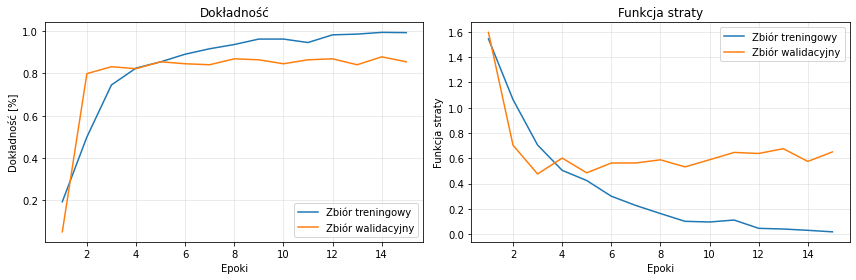

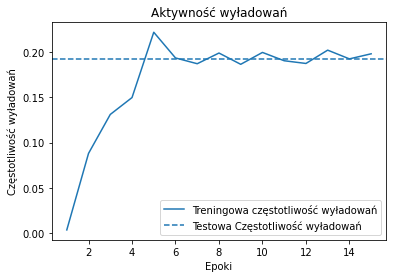

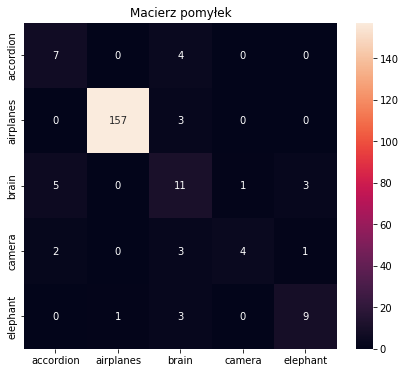

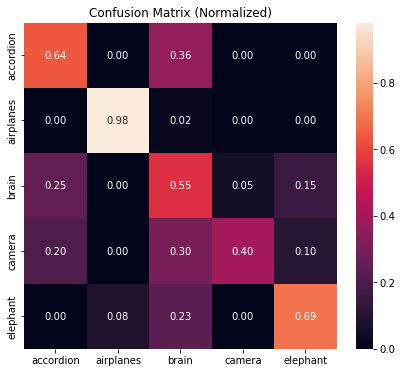

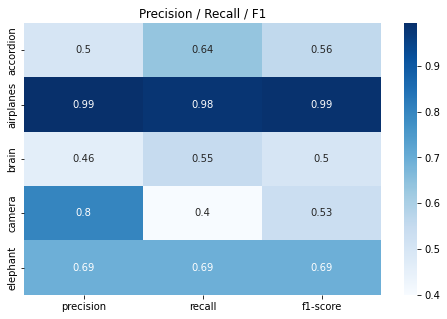

In [4]:
# =========================
# 📦 IMPORTY
# =========================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix

# =========================
# ⚙️ KONFIG
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_ROOT = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\train"
TEST_ROOT  = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\test"

SAVE_DIR   = Path(r"C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real-5-weighted")
SAVE_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"
BEST_MODEL_PATH = SAVE_DIR / "best_model.pth"

# =========================
# 📂 DATASET
# =========================
def load_bin_events(path):
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]

    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)

    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)

    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid  = raw[3::5].astype(np.uint32)
    t_low  = raw[4::5].astype(np.uint32)
    t = (t_high << 16) | (t_mid << 8) | t_low

    return x, y, t.astype(np.float32), p


class EventDatasetBIN(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W

        self.samples = []
        for cls in classes:
            for f in (self.root_dir / cls).glob("*.bin"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_bin_events(path)

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, 10), dtype=np.float32)
        time_bins = (t * 9).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, 5.0)
        voxels /= 5.0

        return torch.from_numpy(voxels), torch.tensor(label)

# =========================
# 🧠 MODEL
# =========================
class SimpleSNN(nn.Module):
    def __init__(self, num_classes, T=10):
        super().__init__()
        self.T = T
        beta = 0.9
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, stride=2, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x = self.lif1(self.conv1(dummy))[0]
            x = self.lif2(self.conv2(x))[0]
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []

        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)

            flat = spk2.flatten(1)
            spk_out, mem_out = self.lif_out(self.fc(flat), mem_out)

            spk_rec.append(spk_out)

        return torch.stack(spk_rec)

# =========================
# 📊 EVALUATE
# =========================
def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_preds = []
    spike_rates = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            spk = model(x)
            sum_spk = spk.sum(dim=0)

            preds = sum_spk.argmax(dim=1)
            rate = spk.mean(dim=(0,2))

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            spike_rates.append(rate.cpu())

    return np.array(all_labels), np.array(all_preds), torch.cat(spike_rates)

# =========================
# 📥 LOAD
# =========================
CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)

test_loader = DataLoader(EventDatasetBIN(TEST_ROOT, CLASSES), batch_size=16)

model = SimpleSNN(NUM_CLASSES).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

best_model = SimpleSNN(NUM_CLASSES).to(device)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# =========================
# 📊 TRAINING PLOTS
# =========================
epochs = history["epoch"]

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Zbiór treningowy")
plt.plot(epochs, history["val_acc"], label="Zbiór walidacyjny")
plt.title("Dokładność")
plt.xlabel("Epoki")
plt.ylabel("Dokładność [%]")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Zbiór treningowy")
plt.plot(epochs, history["val_loss"], label="Zbiór walidacyjny")
plt.title("Funkcja straty")
plt.xlabel("Epoki")
plt.ylabel("Funkcja straty")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "accuracy_loss.png", dpi=300)
plt.show()

# =========================
# ⚡ SPIKE RATE (FIXED)
# =========================
labels, preds, spike_rates = evaluate(best_model, test_loader)

train_spike = history["spike_rate"]
test_spike = spike_rates.mean().item()

plt.figure()

plt.plot(epochs, train_spike, label="Treningowa częstotliwość wyładowań")
plt.axhline(y=test_spike, linestyle="--", label="Testowa Częstotliwość wyładowań")

plt.xlabel("Epoki")
plt.ylabel("Częstotliwość wyładowań")
plt.title("Aktywność wyładowań")
plt.legend()

plt.savefig(SAVE_DIR / "spike_rate_train_test.png")
plt.show()

# =========================
# 🔥 CONFUSION MATRIX
# =========================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title("Macierz pomyłek")
plt.savefig(SAVE_DIR / "confusion_matrix.png")
plt.show()

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title("Confusion Matrix (Normalized)")
plt.savefig(SAVE_DIR / "confusion_matrix_norm.png")
plt.show()

# =========================
# 📊 F1 / PRECISION / RECALL
# =========================
report = classification_report(labels, preds, target_names=CLASSES, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3]

plt.figure(figsize=(8,5))
sns.heatmap(df[["precision","recall","f1-score"]],
            annot=True, cmap="Blues")
plt.title("Precision / Recall / F1")
plt.savefig(SAVE_DIR / "f1_scores.png")
plt.show()

# =========================
# 💾 RAPORT
# =========================
with open(SAVE_DIR / "classification_report.txt", "w") as f:
    f.write(classification_report(labels, preds, target_names=CLASSES))

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =========================
# 📊 GLOBAL METRICS
# =========================

acc = accuracy_score(labels, preds)
precision_macro = precision_score(labels, preds, average="macro")
recall_macro = recall_score(labels, preds, average="macro")
f1_macro = f1_score(labels, preds, average="macro")

precision_weighted = precision_score(labels, preds, average="weighted")
recall_weighted = recall_score(labels, preds, average="weighted")
f1_weighted = f1_score(labels, preds, average="weighted")

print("===== GLOBAL METRICS =====")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro)   : {recall_macro:.4f}")
print(f"F1 (macro)       : {f1_macro:.4f}")

print("\n===== WEIGHTED (lepsze przy imbalance) =====")
print(f"Precision        : {precision_weighted:.4f}")
print(f"Recall           : {recall_weighted:.4f}")
print(f"F1               : {f1_weighted:.4f}")

===== GLOBAL METRICS =====
Accuracy        : 0.8785
Precision (macro): 0.6889
Recall (macro)   : 0.6520
F1 (macro)       : 0.6546

===== WEIGHTED (lepsze przy imbalance) =====
Precision        : 0.8909
Recall           : 0.8785
F1               : 0.8808


# eksperymenty pilotażowe - syntetyczne

C:\Users\Kacper\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


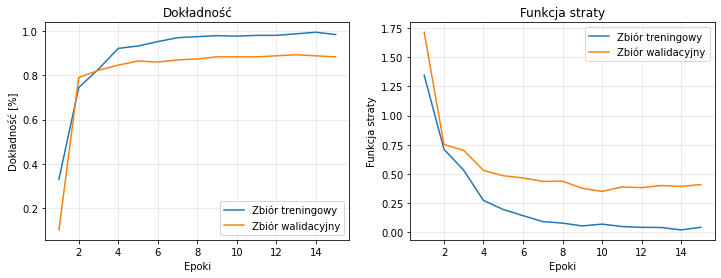

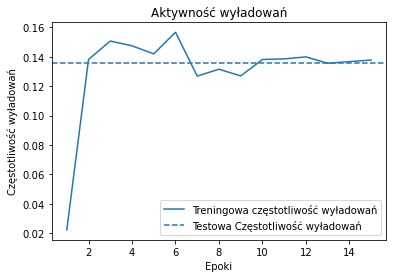

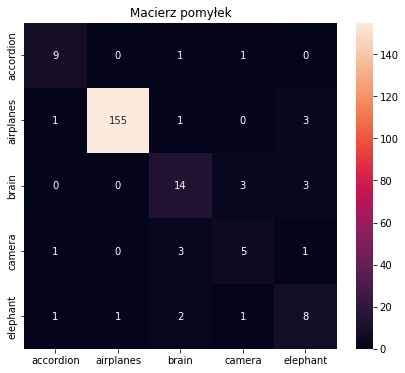

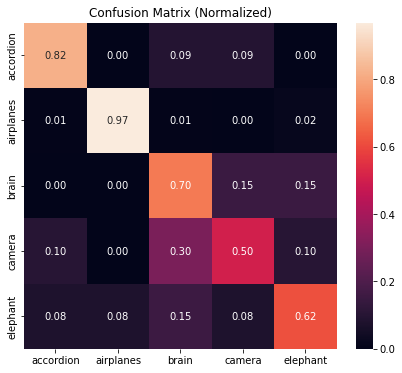

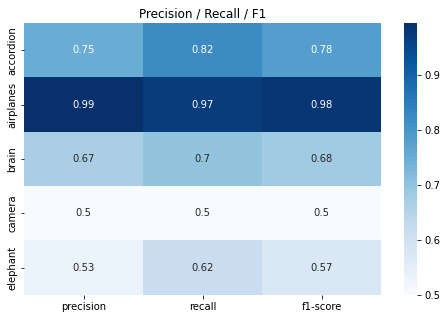

===== GLOBAL METRICS =====
Accuracy        : 0.8925
Precision (macro): 0.6887
Recall (macro)   : 0.7205
F1 (macro)       : 0.7036

===== WEIGHTED (lepsze przy imbalance) =====
Precision        : 0.8995
Recall           : 0.8925
F1               : 0.8956

===== FINAL METRICS =====
Train accuracy : 0.9836
Val accuracy   : 0.8832
Train loss     : 0.0443
Val loss       : 0.4096


In [1]:
# =========================
# 📦 IMPORTY
# =========================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate
import pandas as pd


from torch.utils.data import Dataset, DataLoader
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import h5py

# =========================
# ⚙️ KONFIG
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_ROOT = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS-5class-split\train"
TEST_ROOT  = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS-5class-split\test"

SAVE_DIR = Path(r"C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-synthetic_5-weighte")
SAVE_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"
BEST_MODEL_PATH = SAVE_DIR / "best_model.pth"

# =========================
# 📂 DATA
# =========================
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W

        self.samples = []
        for cls in classes:
            for f in (self.root_dir / cls).glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, 5.0)
        voxels /= 5.0

        return torch.from_numpy(voxels), torch.tensor(label)

# =========================
# 🧠 MODEL
# =========================
class SimpleSNN(nn.Module):
    def __init__(self, num_classes, T=10):
        super().__init__()
        self.T = T
        beta = 0.9
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, stride=2, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x = self.lif1(self.conv1(dummy))[0]
            x = self.lif2(self.conv2(x))[0]
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []

        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)

            flat = spk2.flatten(1)
            spk_out, mem_out = self.lif_out(self.fc(flat), mem_out)

            spk_rec.append(spk_out)

        return torch.stack(spk_rec)

# =========================
# 📊 EVALUATE
# =========================
def evaluate(model, loader):
    model.eval()

    labels, preds, probs = [], [], []
    spike_rates = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            spk = model(x)
            sum_spk = spk.sum(dim=0)

            p = F.softmax(sum_spk, dim=1)
            pr = p.argmax(dim=1)

            labels.extend(y.cpu().numpy())
            preds.extend(pr.cpu().numpy())
            probs.extend(p.cpu().numpy())

            spike_rates.append(spk.mean(dim=(0,2)).cpu())

    return np.array(labels), np.array(preds), np.array(probs), torch.cat(spike_rates)

# =========================
# 📥 DATA
# =========================
CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)

test_loader = DataLoader(EventDatasetH5(TEST_ROOT, CLASSES), batch_size=16)

model = SimpleSNN(NUM_CLASSES).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

best_model = SimpleSNN(NUM_CLASSES).to(device)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
# =========================
# 📊 TRAINING PLOTS
# =========================
epochs = history["epoch"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Zbiór treningowy")
plt.plot(epochs, history["val_acc"], label="Zbiór walidacyjny")
plt.title("Dokładność")
plt.xlabel("Epoki")
plt.ylabel("Dokładność [%]")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Zbiór treningowy")
plt.plot(epochs, history["val_loss"], label="Zbiór walidacyjny")
plt.title("Funkcja straty")
plt.xlabel("Epoki")
plt.ylabel("Funkcja straty")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(SAVE_DIR / "accuracy_loss.png")
plt.show()

# =========================
# ⚡ SPIKE RATE (FIXED)
# =========================
labels, preds, probs, spike_rates = evaluate(best_model, test_loader)

train_spike = history["spike_rate"]
test_spike = spike_rates.mean().item()

plt.figure()

plt.plot(epochs, train_spike, label="Treningowa częstotliwość wyładowań")
plt.axhline(y=test_spike, linestyle="--", label="Testowa Częstotliwość wyładowań")

plt.xlabel("Epoki")
plt.ylabel("Częstotliwość wyładowań")
plt.title("Aktywność wyładowań")
plt.legend()

plt.savefig(SAVE_DIR / "spike_rate_train_test.png")
plt.show()

# =========================
# 🔥 CONFUSION MATRIX
# =========================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title("Macierz pomyłek")
plt.savefig(SAVE_DIR / "confusion_matrix.png")
plt.show()

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title("Confusion Matrix (Normalized)")
plt.savefig(SAVE_DIR / "confusion_matrix_norm.png")
plt.show()

# =========================
# 📊 F1 / PRECISION / RECALL
# =========================
report = classification_report(labels, preds, target_names=CLASSES, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3]

plt.figure(figsize=(8,5))
sns.heatmap(df[["precision","recall","f1-score"]],
            annot=True, cmap="Blues")
plt.title("Precision / Recall / F1")
plt.savefig(SAVE_DIR / "f1_scores.png")
plt.show()

# =========================
# 💾 RAPORT
# =========================
with open(SAVE_DIR / "classification_report.txt", "w") as f:
    f.write(classification_report(labels, preds, target_names=CLASSES))
    
    
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =========================
# 📊 GLOBAL METRICS
# =========================

acc = accuracy_score(labels, preds)
precision_macro = precision_score(labels, preds, average="macro")
recall_macro = recall_score(labels, preds, average="macro")
f1_macro = f1_score(labels, preds, average="macro")

precision_weighted = precision_score(labels, preds, average="weighted")
recall_weighted = recall_score(labels, preds, average="weighted")
f1_weighted = f1_score(labels, preds, average="weighted")

print("===== GLOBAL METRICS =====")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro)   : {recall_macro:.4f}")
print(f"F1 (macro)       : {f1_macro:.4f}")

print("\n===== WEIGHTED (lepsze przy imbalance) =====")
print(f"Precision        : {precision_weighted:.4f}")
print(f"Recall           : {recall_weighted:.4f}")
print(f"F1               : {f1_weighted:.4f}")

train_acc_final = history["train_acc"][-1]
val_acc_final = history["val_acc"][-1]

train_loss_final = history["train_loss"][-1]
val_loss_final = history["val_loss"][-1]

print("\n===== FINAL METRICS =====")

print(f"Train accuracy : {train_acc_final:.4f}")
print(f"Val accuracy   : {val_acc_final:.4f}")

print(f"Train loss     : {train_loss_final:.4f}")
print(f"Val loss       : {val_loss_final:.4f}")

# ResNet

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
# import h5py # Nadal importowane, choć dla BIN nieużywane w datasecie
import math
from scipy.stats import pearsonr # For correlation

# --- FUNKCJE I KLASY DLA DANYCH RZECZYWISTYCH (.BIN) ---
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    if not self.root_dir.exists():
        print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
        return

    for cls in classes:
        class_path = self.root_dir / cls
        if not class_path.exists():
            print(f"Ostrzeżenie: Katalog klasy {class_path} nie istnieje. Pomijam.")
            continue
        for f in class_path.glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))
    
    if not self.samples:
        print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .bin).")

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if len(t) == 0:
          return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t_min = t.min()
      t_max = t.max()
      if (t_max - t_min) < 1e-9:
          t_normalized = np.zeros_like(t)
      else:
          t_normalized = (t - t_min) / (t_max - t_min)
          
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      voxels *= 1.5

      return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH RZECZYWISTYCH ---


# --- Definicje dla ResNet SNN ---
class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, **kwargs):
        super().__init__()
        self.thresh = thresh
        self.tau = tau
        self.mem = None
        self.spike = None
        self.spike_fn = snn.Leaky(beta=self.tau, threshold=self.thresh, spike_grad=surrogate.fast_sigmoid())

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = B

        spikes_output = []
        mem_curr = self.spike_fn.init_leaky().to(x.device)
        for t in range(x.shape[1]):
            spike_t, mem_curr = self.spike_fn(x[:, t, ...], mem_curr)
            spikes_output.append(spike_t)
            self.total_spikes += spike_t.sum().item()
        return torch.stack(spikes_output, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dropout_p=0.3, **lif_parameters):
        super().__init__()
        filtered_lif_parameters = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**filtered_lif_parameters)
        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**filtered_lif_parameters)
        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout1(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.conv2(out.contiguous().view(B*T, *out.shape[2:]))
        out = self.bn2(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.dropout2(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        shortcut_out = self.shortcut(x_flat_for_conv_bn).view(B, T, -1, *out.shape[3:]) if len(self.shortcut) > 0 else x

        out += shortcut_out
        return out

class ResNet_SNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=101, in_channels=2, dropout_p=0.3, **lif_parameters):
        super().__init__()
        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get('T', 10)

        filtered_lif_parameters_for_lif_node = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**filtered_lif_parameters_for_lif_node)
        self.dropout_initial = nn.Dropout2d(p=self.dropout_p)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block_module in layer.children():
                if isinstance(block_module, BasicBlock):
                    self.lif_modules.append(block_module.spike1)
                    self.lif_modules.append(block_module.spike2)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def _make_layer(self, block, planes, num_blocks, stride, dropout_p, **lif_parameters):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_planes, planes, stride_val, dropout_p=dropout_p, **lif_parameters))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout_initial(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out_flat = out.contiguous().view(B*T, *out.shape[2:])
        out_pooled = self.avgpool(out_flat)
        out_final = self.flatten(out_pooled)
        out_final = self.linear(out_final)

        out_reshaped = out_final.view(B, T, -1)
        return out_reshaped


# Factory functions
def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)

def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)

# --- Koniec definicji ResNet SNN ---

def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- Konfiguracja dla wizualizacji ---
# --- ZMIANA: Wymuszenie użycia CPU ---
device = torch.device("cpu")
print(f"Używane urządzenie: {device} (wymuszone CPU ze względu na błędy CUDA)")

# --- ZMIANA: Usunięcie ustawień CUDA backend ---
# torch.backends.cudnn.benchmark = True
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.set_float32_matmul_precision("high")

# Ścieżki bazowe dla wyników i wykresów
BASE_SNN_DIR = Path(r"C:\Users\Kacper\OneDrive\Desktop\SNN")
EXPERIMENT_NAME = "results-real_ResNet" # Zmieniona nazwa eksperymentu

RESULTS_DIR = BASE_SNN_DIR / "results" / EXPERIMENT_NAME
PLOTS_DIR = BASE_SNN_DIR / "plots" / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych rzeczywistych (.bin)
TRAIN_ROOT = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "train"
TEST_ROOT  = BASE_SNN_DIR / "data" / "N-Caltech101-full-split" / "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu ResNet18 SNN
DATASET_T = 8 # Zgodnie z twoim kodem treningowym
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_channels": 2, # Zmieniono z in_c na in_channels dla ResNet
    "thresh": 0.7,
    "tau": 0.95,
    "gamma": 1.0, # Dodano gamma, nawet jeśli LIFNode używa tylko fast_sigmoid, dla spójności
    "dropout_p": 0.1,
    "T": DATASET_T # Ważne, aby T było dostępne dla LIFNode w forward, jeśli używa go
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        # --- ZMIANA: load checkpoint na CPU ---
        checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

# Robustne przetwarzanie historii
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]
    
    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]
            
        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and "epoch" in history and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if "train_loss" in history and "val_loss" in history:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności (bez val_acc)
    if "train_acc" in history: 
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]
            
            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)
            
            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)
    
    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        # --- ZMIANA: load state dict na CPU ---
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location="cpu"))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T, H=180, W=240)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                # --- ZMIANA: num_workers=0, pin_memory=False dla CPU ---
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=False)
                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)
                
                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")
                
                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if isinstance(history["spike_rate"][-1], list):
        final_firing_rates = history["spike_rate"][-1]
        layer_names = [f"LIF {i+1}" for i in range(len(final_firing_rates))]

        plt.figure(figsize=(10, 6), constrained_layout=True)
        sns.barplot(x=layer_names, y=final_firing_rates, palette="viridis")
        plt.xlabel("Warstwa LIF")
        plt.ylabel("Średnia częstość wyładowań")
        plt.title("Średnia częstość wyładowań na warstwę LIF (ostatnia epoka)")
        plt.xticks(rotation=45, ha='right')
        plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
        plt.close()
        print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and "val_acc" in history and "spike_rate" in history and "epoch" in history:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) ResNet18

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** ResNet18 SNN
*   **Zbiór danych:** N-Caltech101 (format BIN)
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device} (wykonano na CPU ze względu na problemy z konfiguracją CUDA)

**Parametry sieci (LIFNode):**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']} | Parametr surrogatowy (`gamma`): {MODEL_PARAMS['gamma']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']}

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (z treningu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (epoka {history["epoch"][np.argmax(history["val_acc"])] if "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average):** {final_precision_weighted*100:.2f}% | (Macro Average): {final_precision_macro*100:.2f}%
*   **Recall (Weighted Average):** {final_recall_weighted*100:.2f}% | (Macro Average): {final_recall_macro*100:.2f}%
*   **F1-Score (Weighted Average):** {final_f1_weighted*100:.2f}% | (Macro Average): {final_f1_macro*100:.2f}%

"""

Używane urządzenie: cpu (wymuszone CPU ze względu na błędy CUDA)
Wykryta liczba klas: 101
Wczytywanie checkpointu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_ResNet\checkpoint.pth...
Błąd podczas wczytywania checkpointu: module 'torch' has no attribute '_utils'
Wczytywanie najlepszego modelu z C:\Users\Kacper\OneDrive\Desktop\SNN\results\results-real_ResNet\best_model.pth do ewaluacji...
Błąd podczas ewaluacji najlepszego modelu: module 'torch' has no attribute 'version'
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
